# örnek veri seti ile spider diyagramı

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [20]:
dataset = pd.read_excel("../spider_tac_1.xlsx", header=1)

In [21]:
dataset.columns = ["Elements", "Primitive Mantle"] + list(dataset.columns[2:])
dataset

,Elements,Primitive Mantle,OIB values,OIB,BASALT,BASALT.1,BASALT.2,BASALT.3,BASALT.4,BASALT.5,...,EG-16,T6-7B rgf Duncker 1991,89sb100,QBW201 Thole menzies 1991,Lm91-101,Lm91-103,CR7-125,CR7-79,SM27 Simcoe,SH270 Shasta
0,Cs,0.0079,0.387,48.987342,NaN,0.19,0.40,NaN,NaN,0.64,...,NaN,NaN,NaN,NaN,NaN,NaN,1.47,0.12,0.359,0.202
1,Rb,0.6350,31.000,48.818898,12.00,10.00,15.00,14.00,23.00,37.00,...,13.00,16.00,26.00,14.00,14.00,9.70,3.97,10.90,37.600,4.700
2,Ba,6.9890,350.000,50.078695,201.00,143.00,335.00,208.00,315.00,407.00,...,264.00,416.00,797.00,153.00,398.00,181.00,329.00,566.00,672.000,122.000
3,Th,0.0850,4.000,47.058824,NaN,1.07,2.73,1.89,NaN,3.36,...,3.50,NaN,13.65,2.20,2.20,1.14,3.53,1.23,3.960,0.640
4,U,0.0210,1.020,48.571429,NaN,0.30,NaN,NaN,NaN,NaN,...,0.70,0.60,2.99,NaN,0.80,0.80,1.42,0.30,1.310,NaN
5,Nb,0.7130,48.000,67.321178,8.60,8.30,13.70,10.80,16.00,19.80,...,12.00,16.00,58.00,10.00,11.00,NaN,17.01,14.85,57.000,2.500
6,Ta,0.0410,2.700,65.853659,NaN,0.37,0.81,0.86,NaN,2.39,...,0.90,NaN,2.51,0.57,0.50,0.13,1.21,3.00,3.770,0.188
7,K,0.0300,1.445,48.166667,0.47,0.47,0.76,0.56,0.94,1.14,...,0.99,1.00,1.04,0.53,0.97,0.80,1.71,0.82,2.250,0.280
8,La,0.6870,37.000,53.857351,10.50,10.10,17.20,12.70,19.30,21.70,...,17.80,20.10,97.00,23.00,18.20,7.53,26.30,20.82,40.900,4.480
9,Ce,1.7750,80.000,45.070423,22.60,22.30,39.50,27.50,46.20,48.30,...,37.90,44.00,201.00,NaN,41.00,16.04,55.37,43.22,86.530,11.850


In [22]:
sample_names = pd.read_excel("../spider_tac_1.xlsx", header=None)
name_row = sample_names.loc[0,4:].reset_index(drop=True)
attribute_row = sample_names.loc[1,4:].reset_index(drop=True)

In [23]:
dataset["Elements"]

0     Cs
1     Rb
2     Ba
3     Th
4      U
5     Nb
6     Ta
7      K
8     La
9     Ce
10    Pb
11    Sr
12     P
13    Nd
14    Sm
15    Zr
16    Hf
17    Eu
18    Ti
19    Tb
20     Y
21    Yb
22    Lu
Name: Elements, dtype: object

In [24]:
pr_mantle = dataset.iloc[:,1]
pr_mantle

0      0.0079
1      0.6350
2      6.9890
3      0.0850
4      0.0210
5      0.7130
6      0.0410
7      0.0300
8      0.6870
9      1.7750
10     0.0710
11    21.1000
12     0.0218
13     1.3540
14     0.4440
15    11.2000
16     0.3090
17     0.1680
18     0.2168
19     0.1080
20     4.5500
21     0.4930
22     0.0740
Name: Primitive Mantle, dtype: float64

In [25]:
N = dataset.columns.size
N

89

In [26]:
normalised_matrix = []

for i in range(4, N):
    calculated =  dataset.iloc[:,i] /  pr_mantle
    normalised_matrix.append(calculated)

In [27]:
normalised_df = pd.DataFrame(normalised_matrix).transpose()
normalised_df

,0,1,2,3,4,5,6,7,8,9,...,75,76,77,78,79,80,81,82,83,84
0,NaN,24.050633,50.632911,NaN,NaN,81.012658,51.898734,NaN,81.012658,49.367089,...,NaN,NaN,NaN,NaN,NaN,NaN,186.075949,15.189873,45.443038,25.569620
1,18.897638,15.748031,23.622047,22.047244,36.220472,58.267717,45.669291,39.370079,44.094488,42.519685,...,20.472441,25.196850,40.944882,22.047244,22.047244,15.275591,6.251969,17.165354,59.212598,7.401575
2,28.759479,20.460724,47.932465,29.761053,45.070826,58.234368,61.239090,50.937187,61.239090,56.946630,...,37.773644,59.522106,114.036343,21.891544,56.946630,25.897839,47.073973,80.984404,96.151095,17.456002
3,NaN,12.588235,32.117647,22.235294,NaN,39.529412,32.588235,NaN,35.294118,37.764706,...,41.176471,NaN,160.588235,25.882353,25.882353,13.411765,41.529412,14.470588,46.588235,7.529412
4,NaN,14.285714,NaN,NaN,NaN,NaN,42.857143,NaN,47.619048,NaN,...,33.333333,28.571429,142.380952,NaN,38.095238,38.095238,67.619048,14.285714,62.380952,NaN
5,12.061711,11.640954,19.214586,15.147265,22.440393,27.769986,25.245442,24.964937,29.733520,24.123422,...,16.830295,22.440393,81.346424,14.025245,15.427770,NaN,23.856942,20.827489,79.943899,3.506311
6,NaN,9.024390,19.756098,20.975610,NaN,58.292683,18.536585,NaN,20.487805,24.634146,...,21.951220,NaN,61.219512,13.902439,12.195122,3.170732,29.512195,73.170732,91.951220,4.585366
7,15.666667,15.666667,25.333333,18.666667,31.333333,38.000000,41.666667,33.333333,37.666667,37.000000,...,33.000000,33.333333,34.666667,17.666667,32.333333,26.666667,57.000000,27.333333,75.000000,9.333333
8,15.283843,14.701601,25.036390,18.486172,28.093159,31.586608,33.478894,24.890830,36.826783,30.858806,...,25.909753,29.257642,141.193595,33.478894,26.491994,10.960699,38.282387,30.305677,59.534207,6.521106
9,12.732394,12.563380,22.253521,15.492958,26.028169,27.211268,28.056338,21.633803,30.591549,28.169014,...,21.352113,24.788732,113.239437,NaN,23.098592,9.036620,31.194366,24.349296,48.749296,6.676056


In [28]:
name_row

0        AB2BUK-1
1         AB2DB-2
2        AB3ADB-4
3        AB4BUK-5
4        AB5DB-14
         ...     
80       Borg1997
81      Camp 2003
82      Camp 2003
83    Bacon  1997
84    Bacon  1997
Name: 0, Length: 85, dtype: object

In [29]:
normalised_df.columns.size, name_row.size, attribute_row.size

(85, 85, 85)

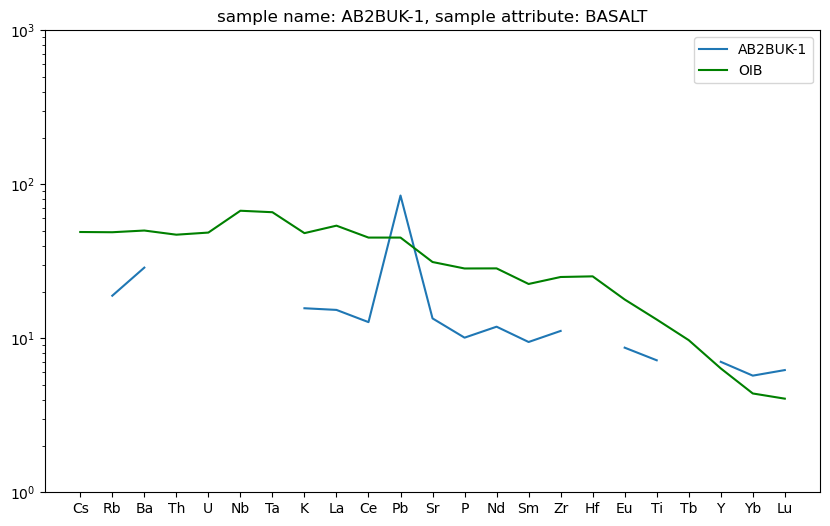

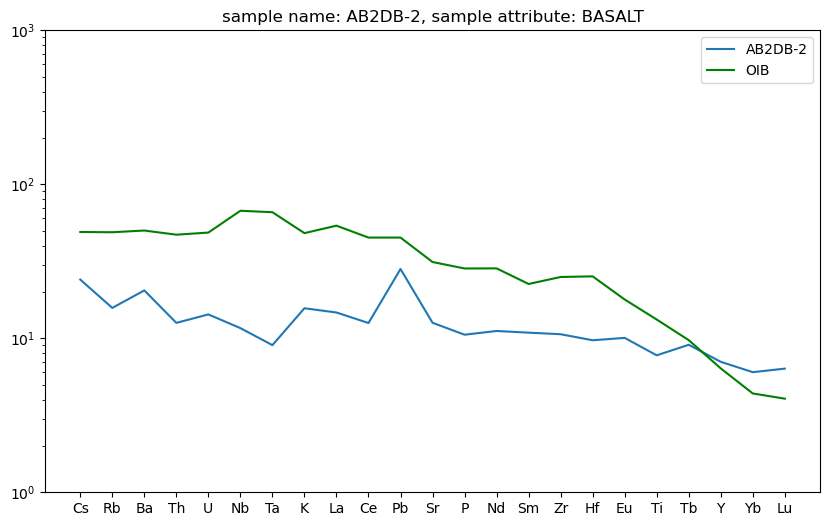

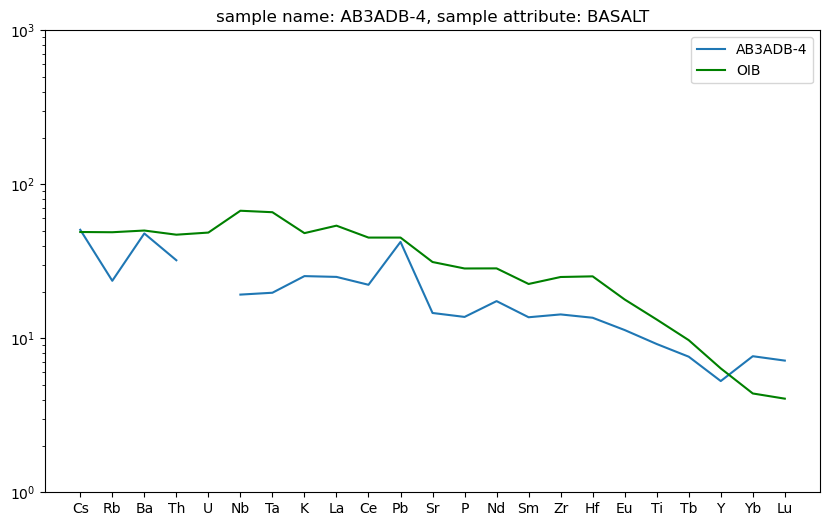

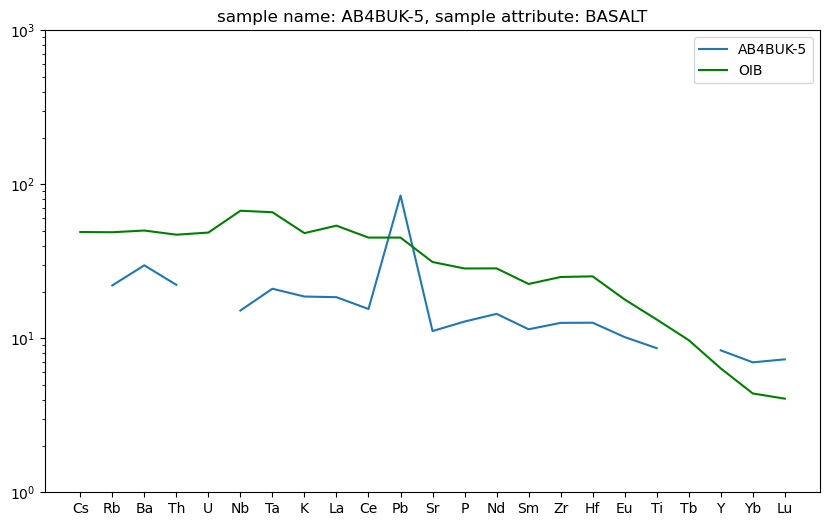

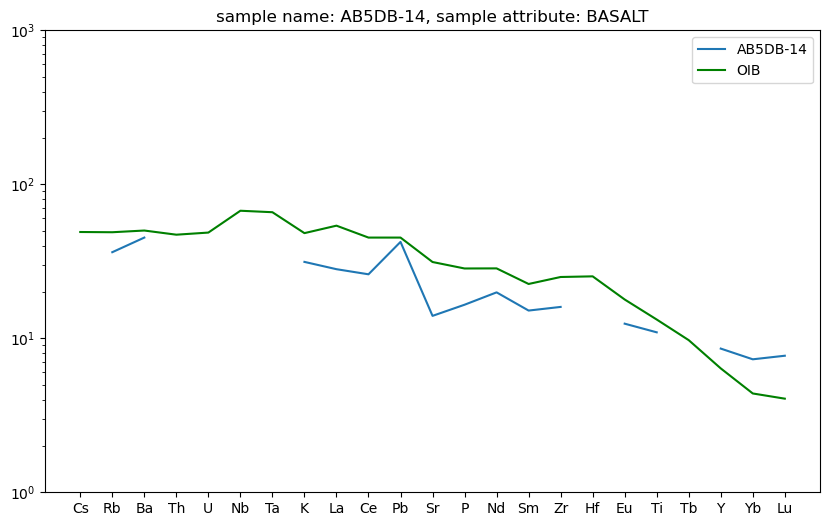

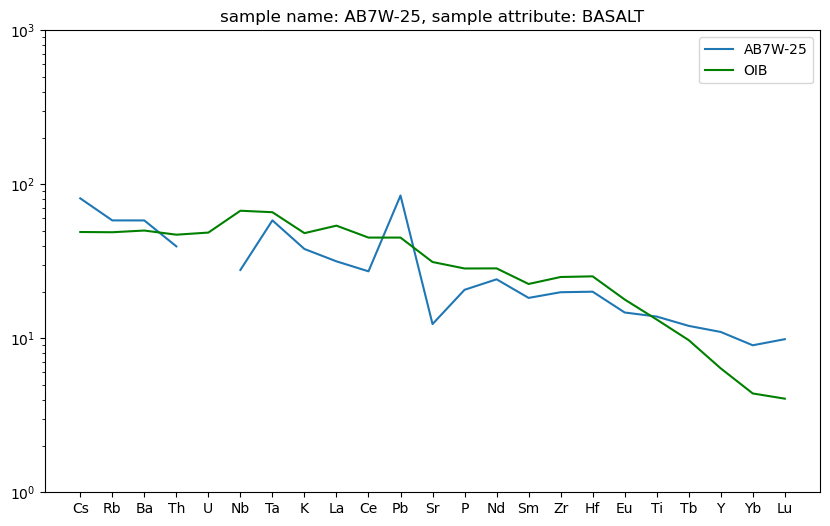

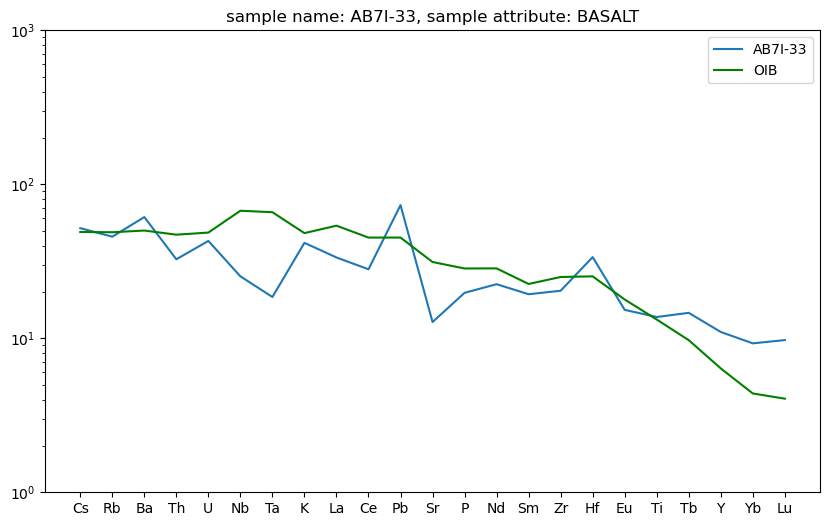

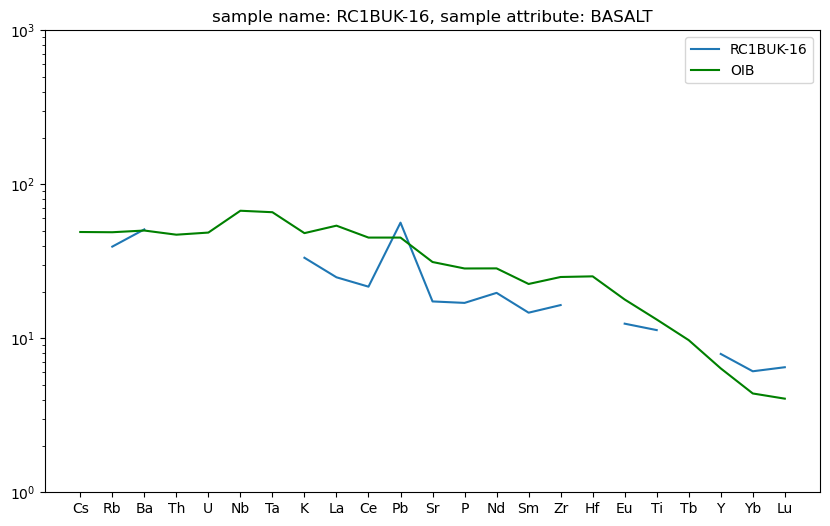

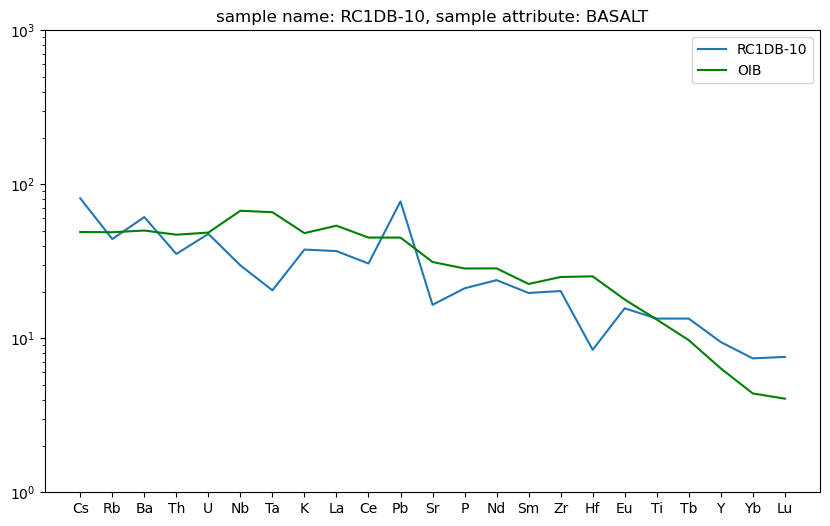

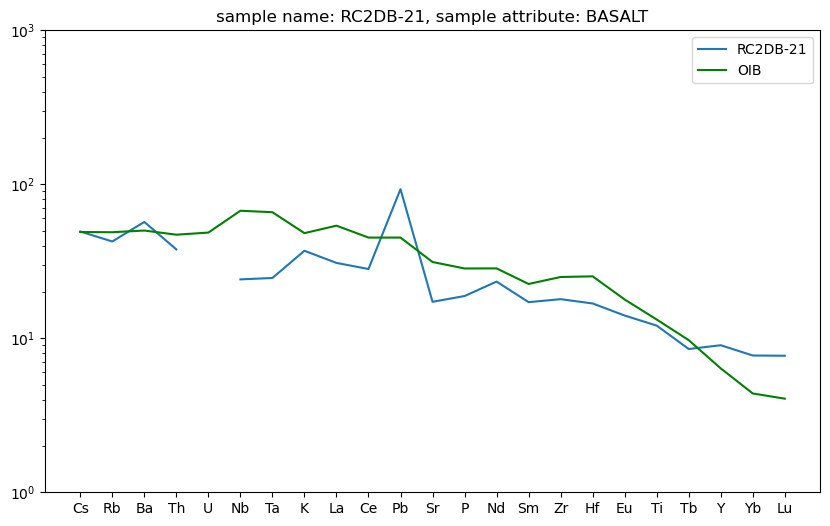

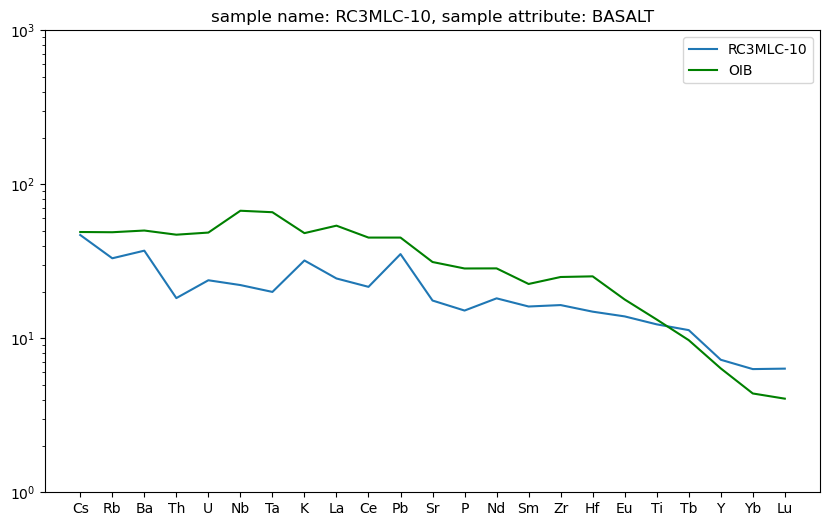

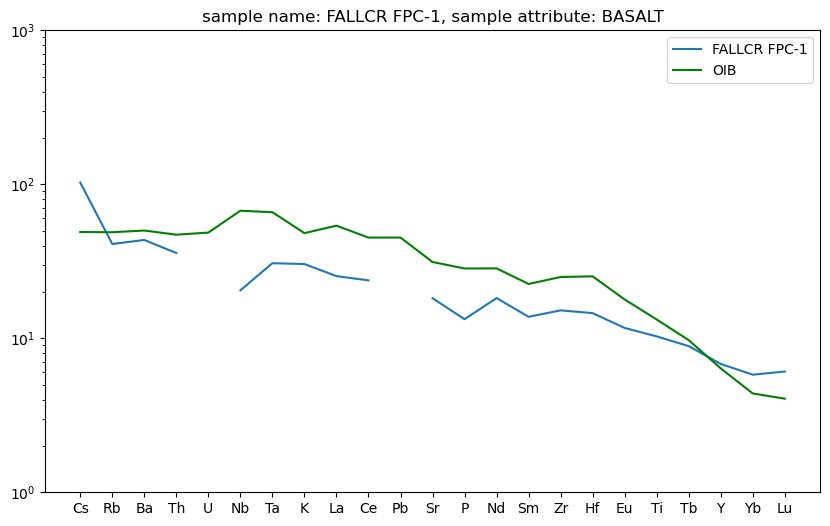

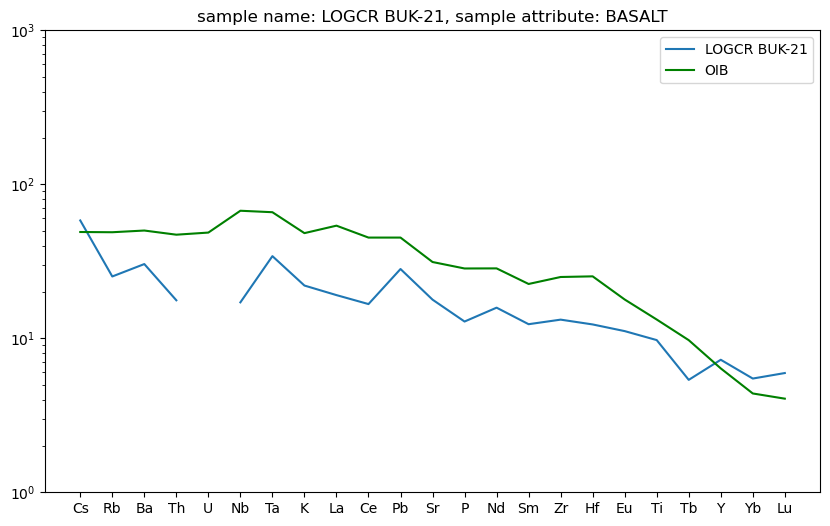

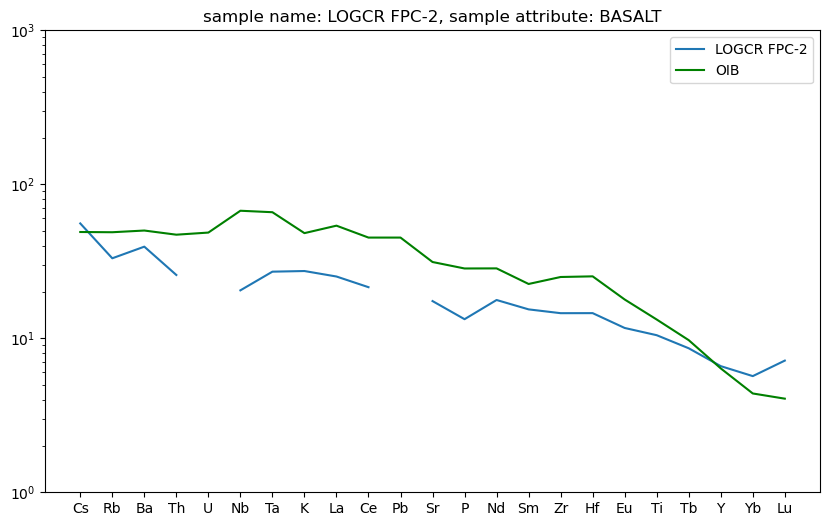

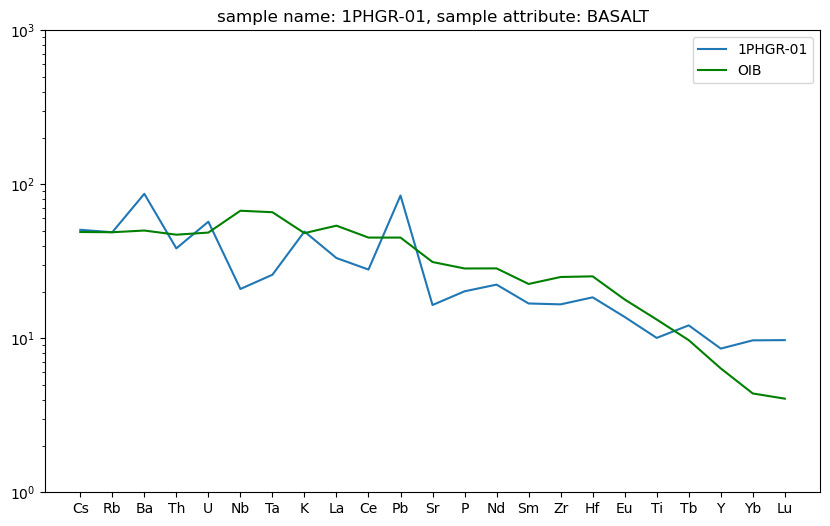

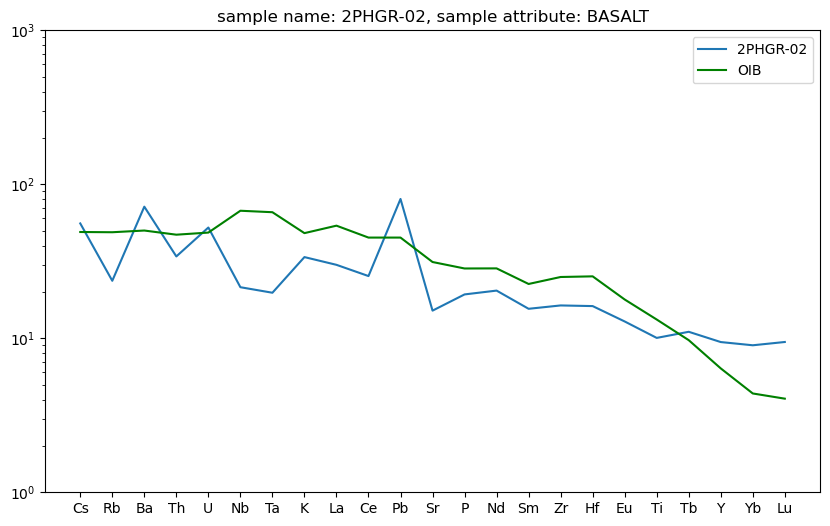

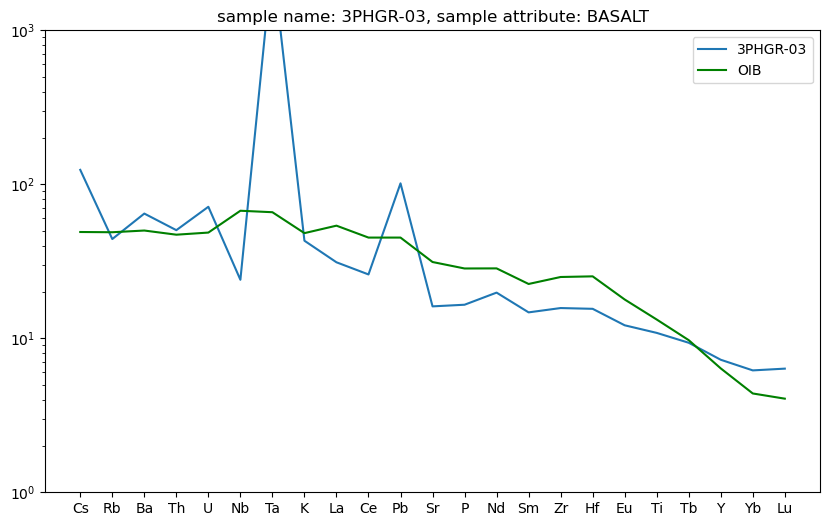

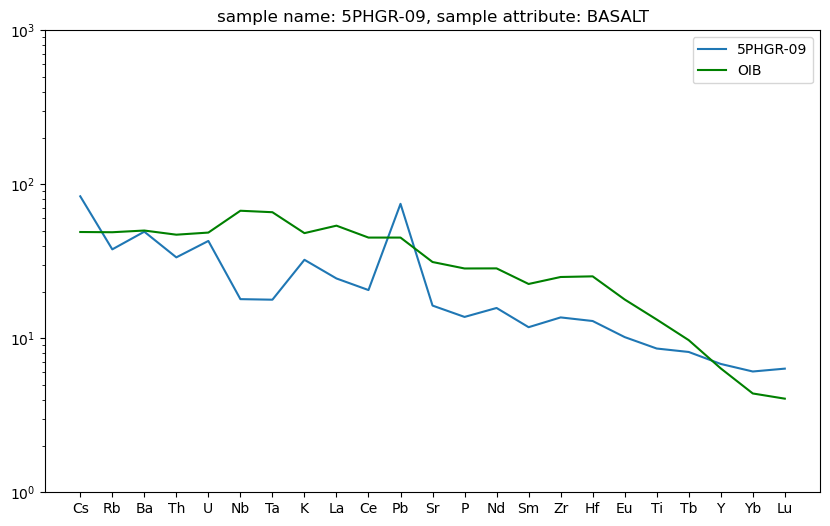

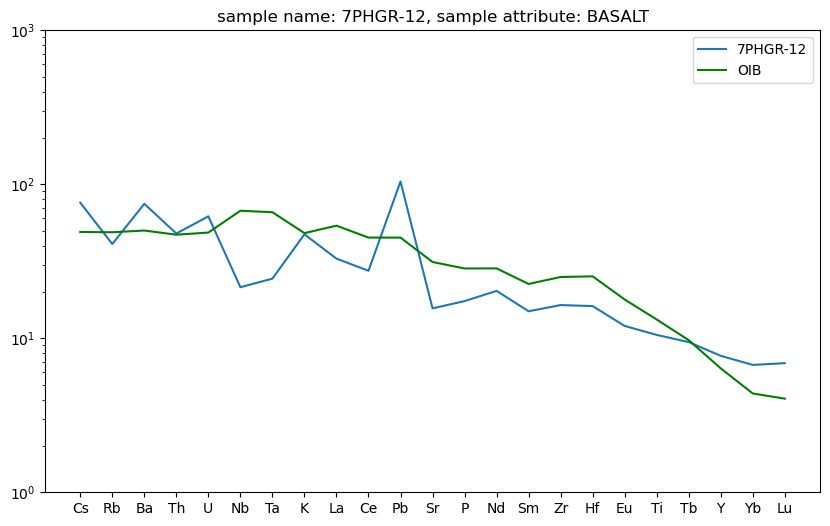

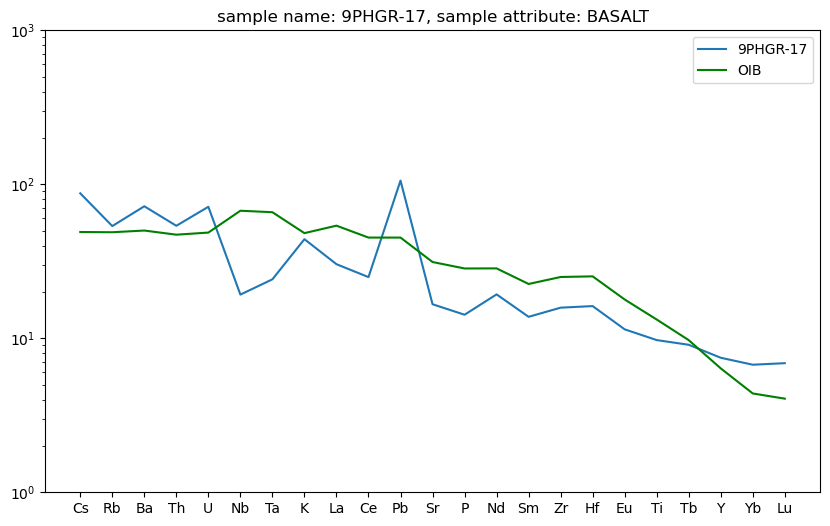

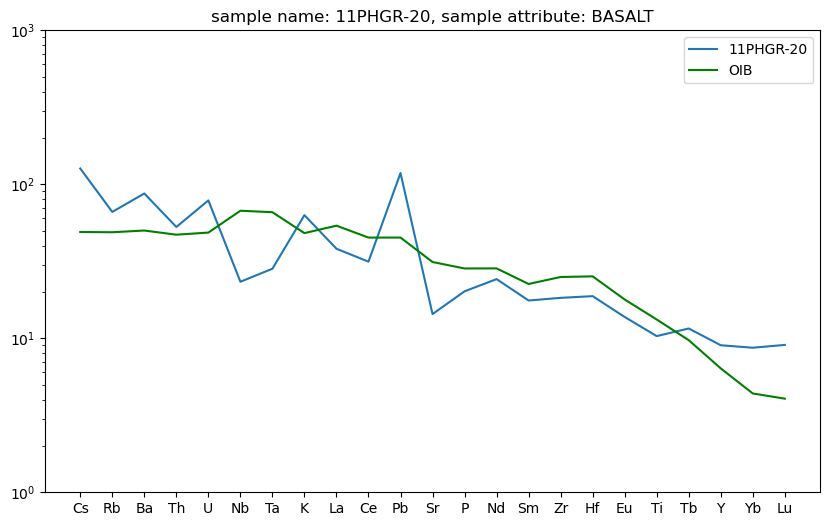

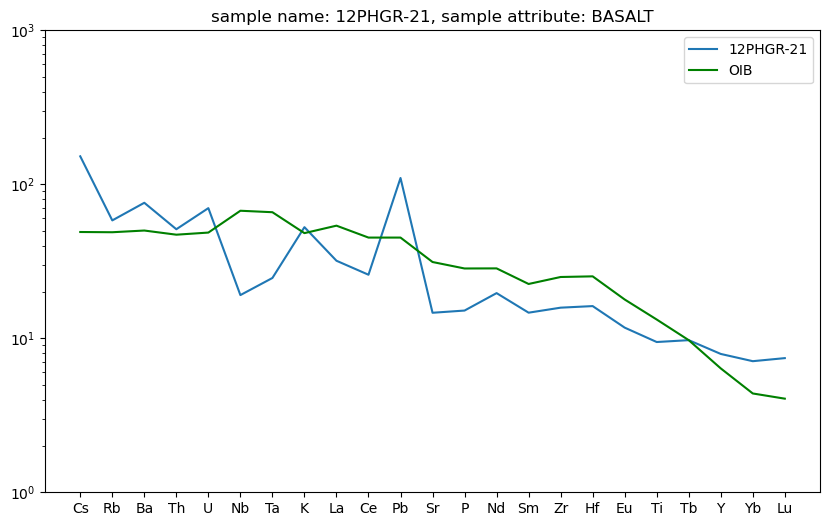

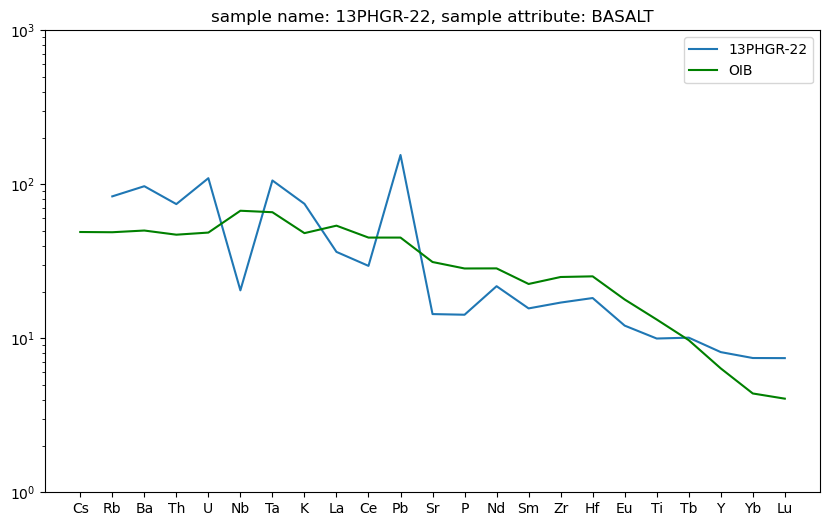

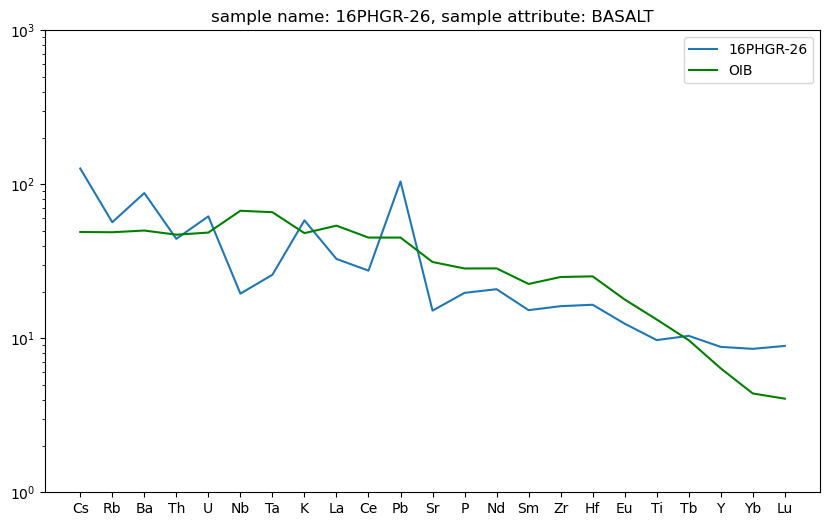

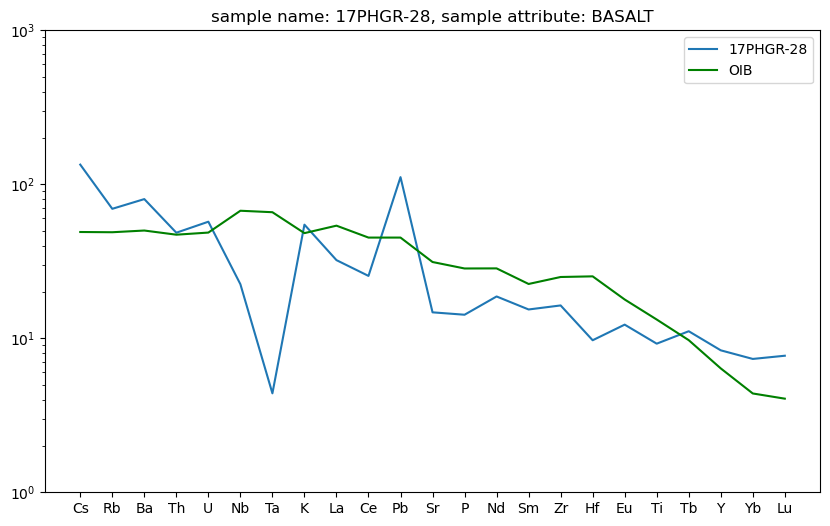

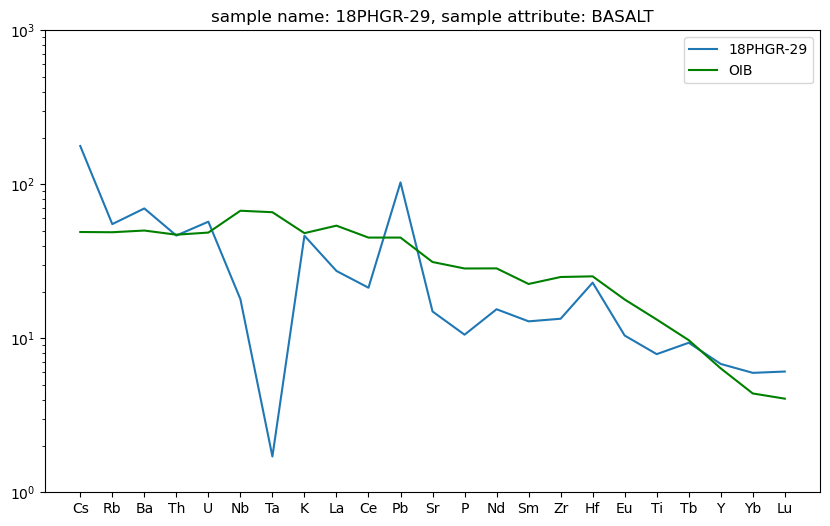

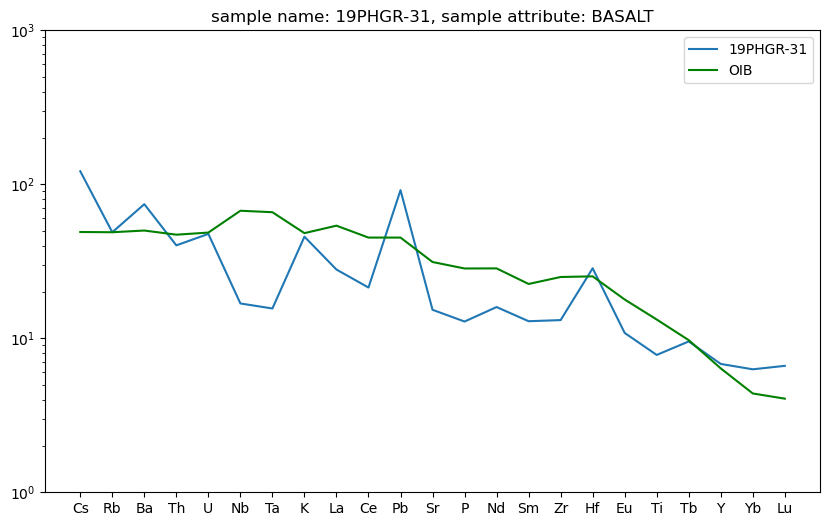

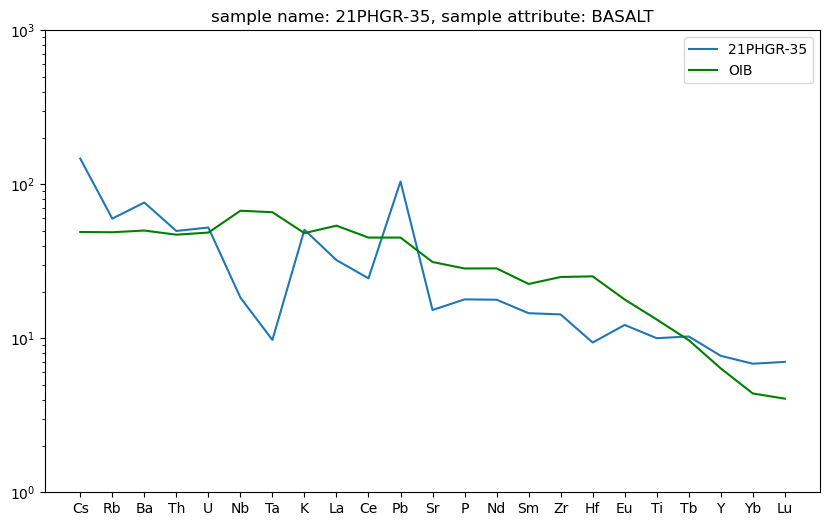

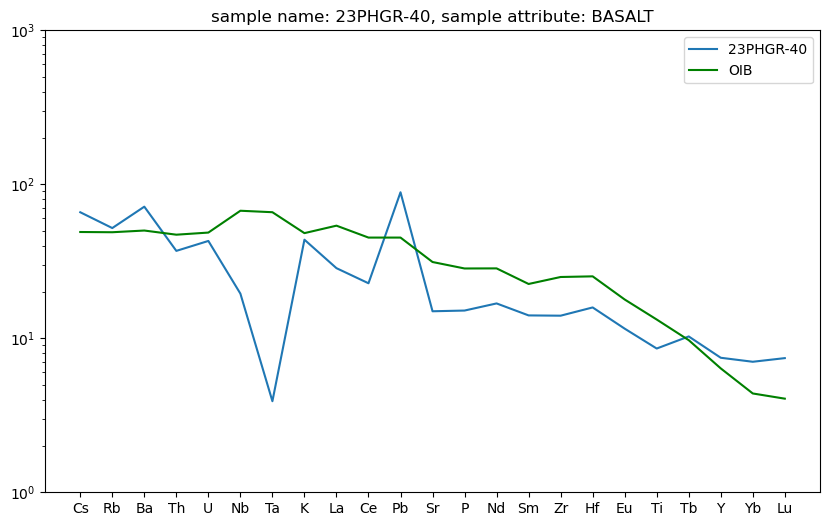

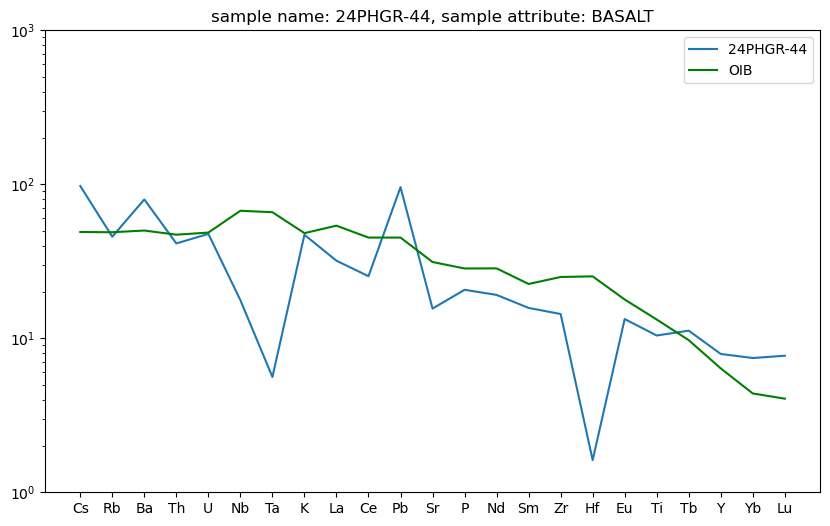

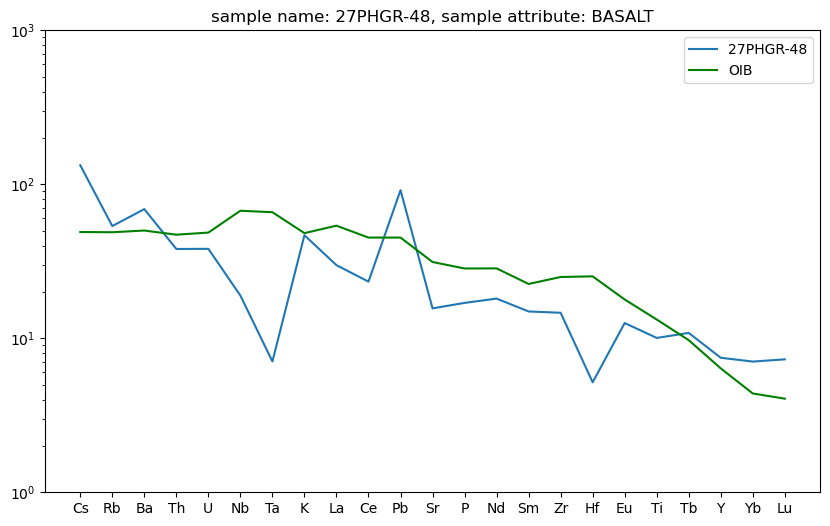

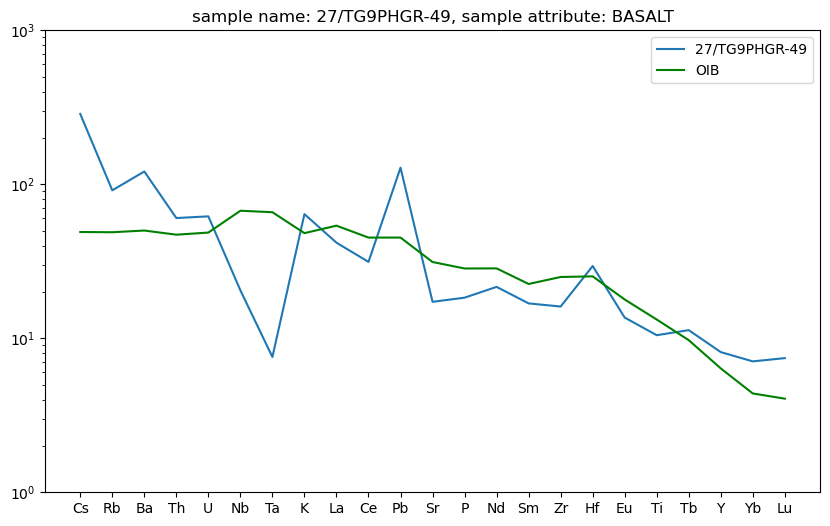

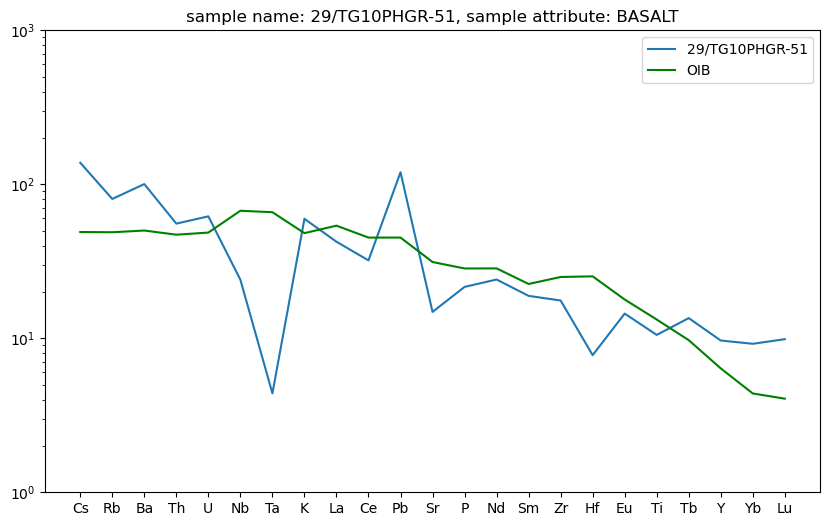

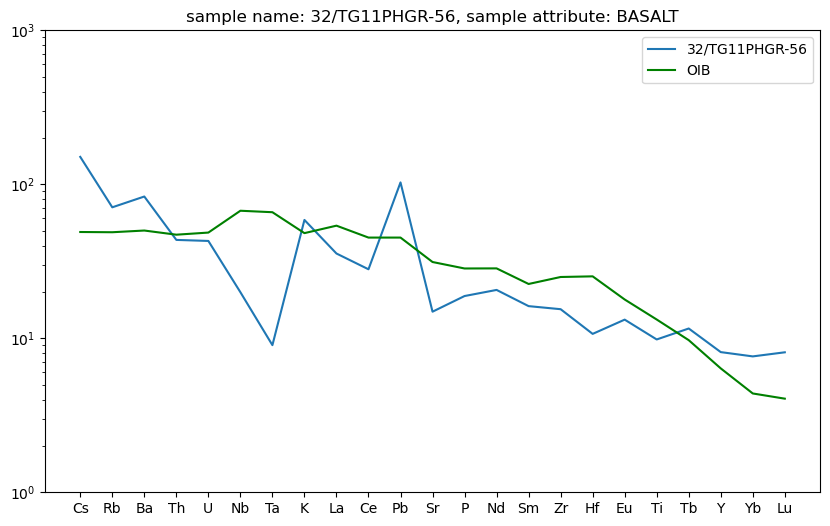

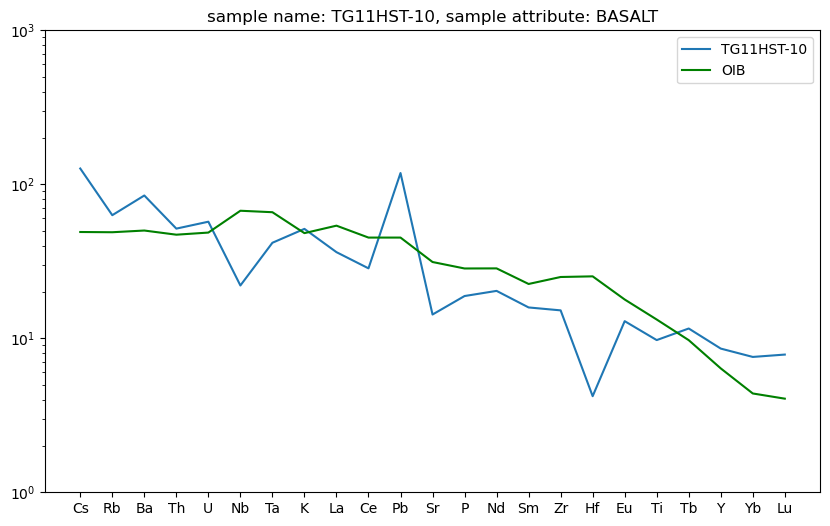

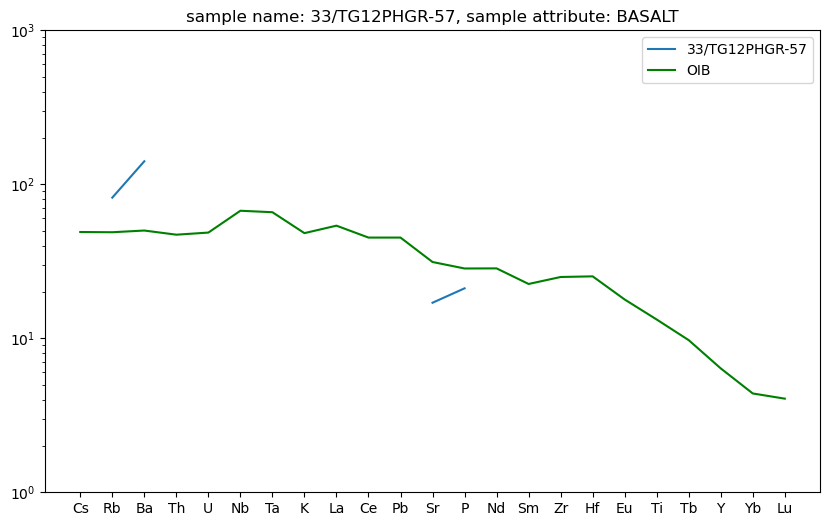

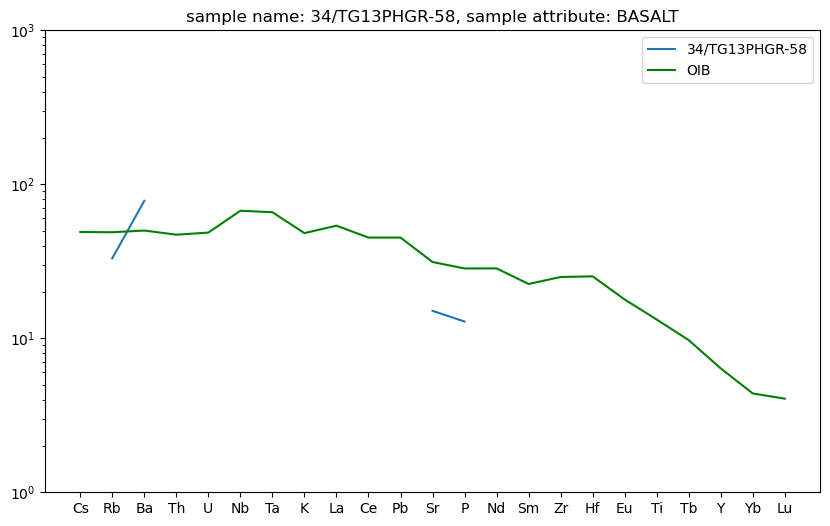

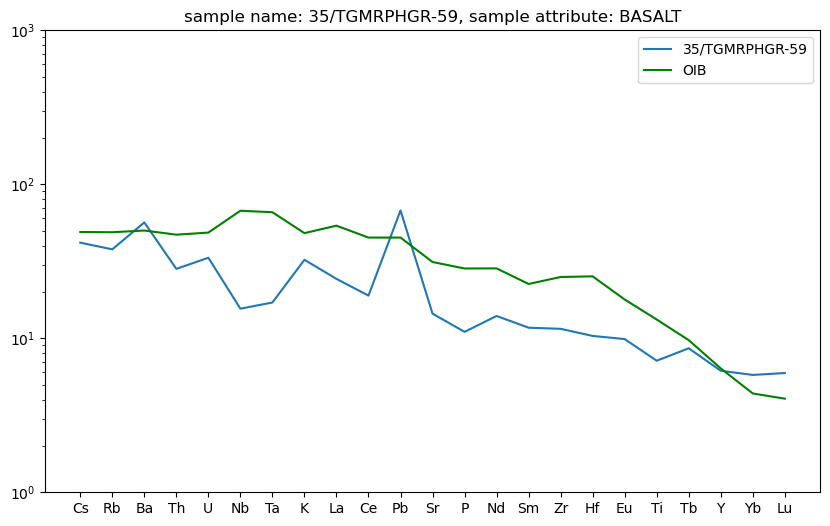

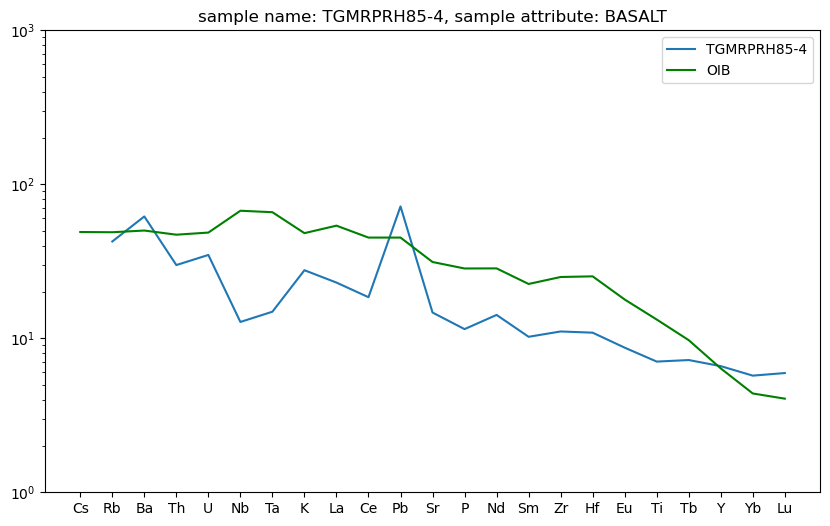

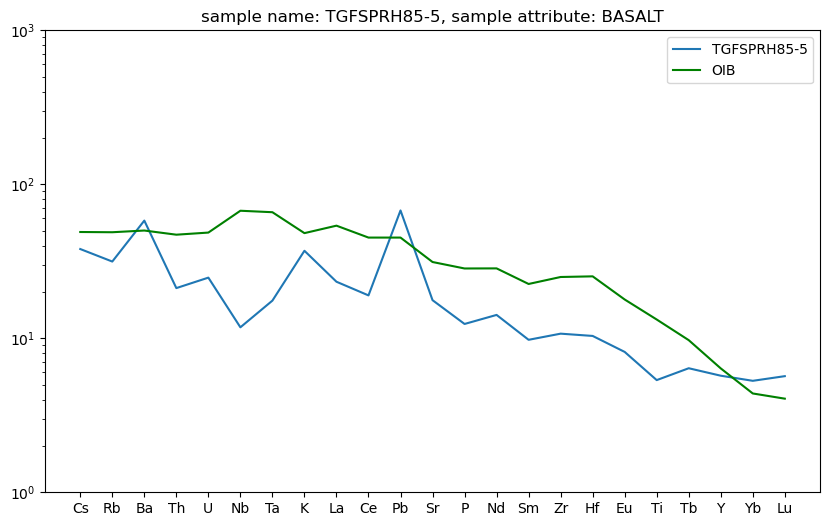

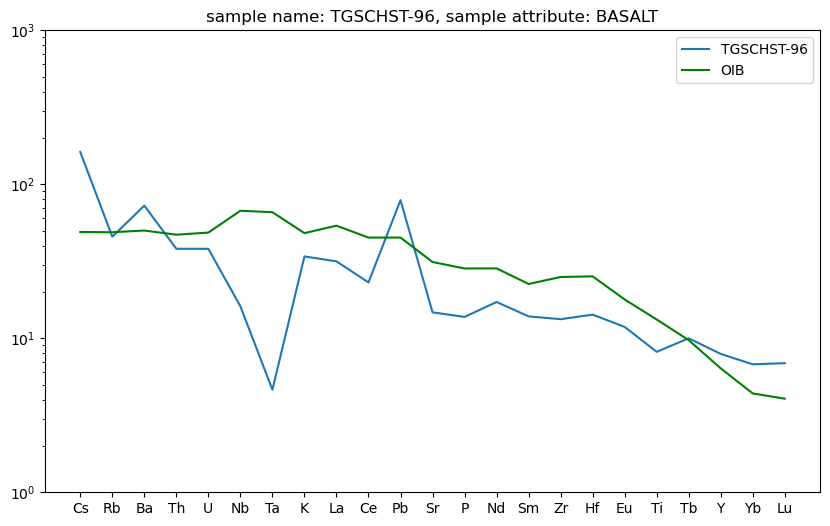

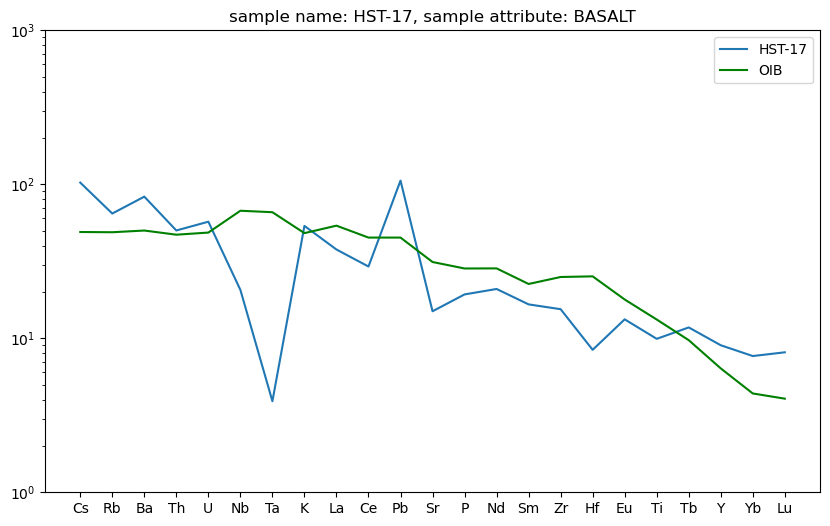

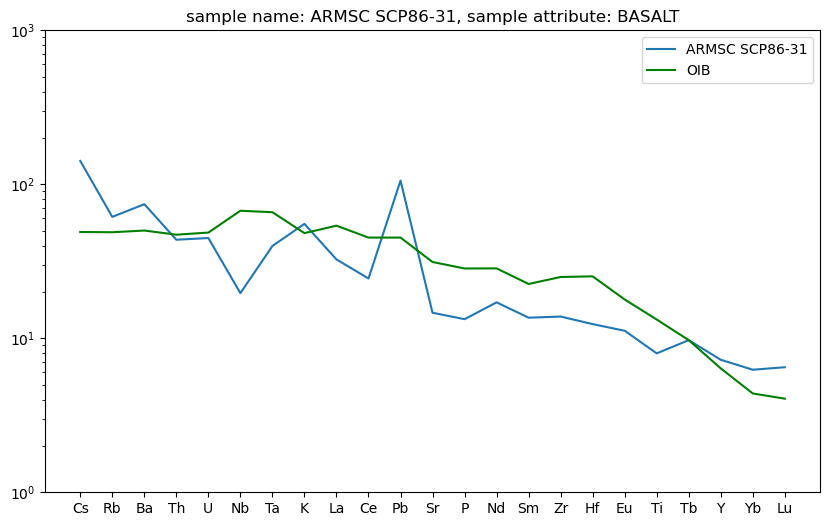

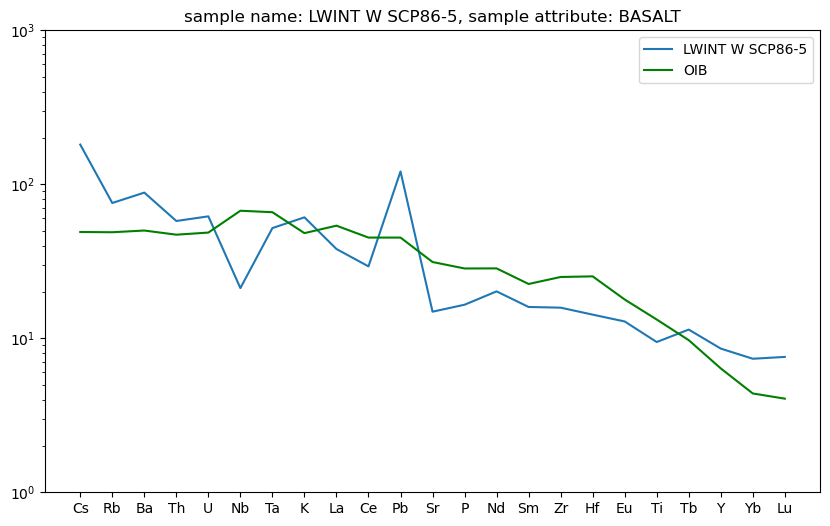

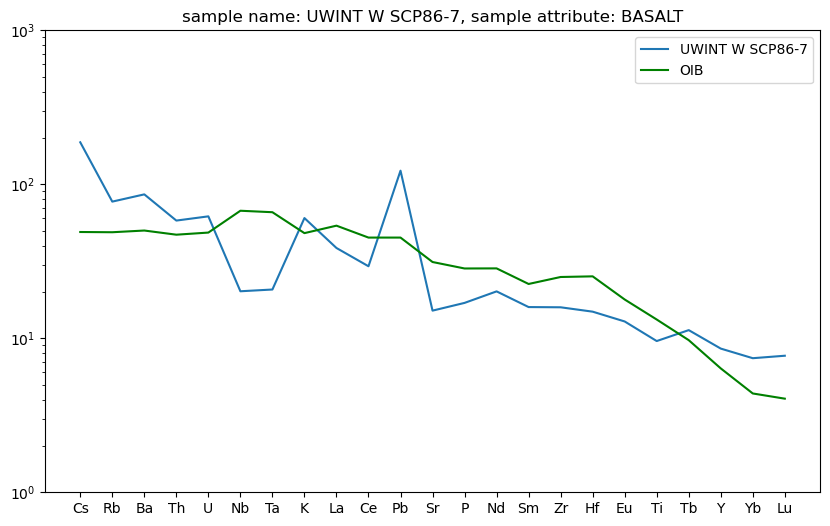

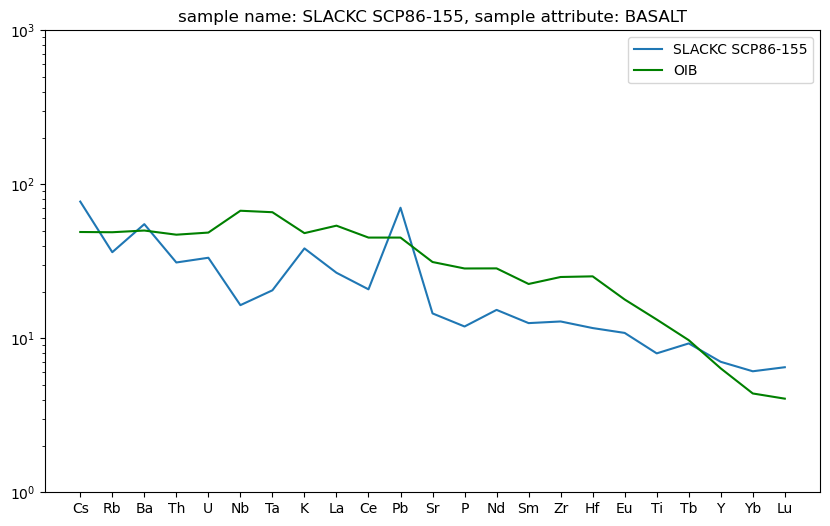

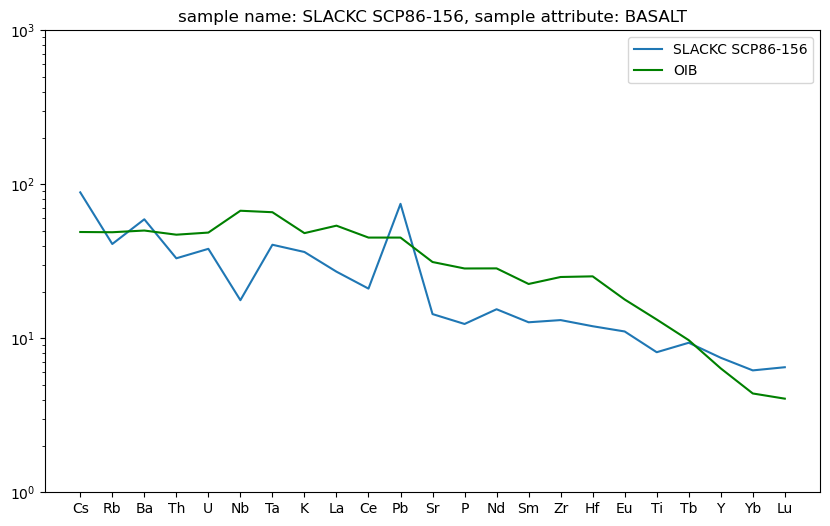

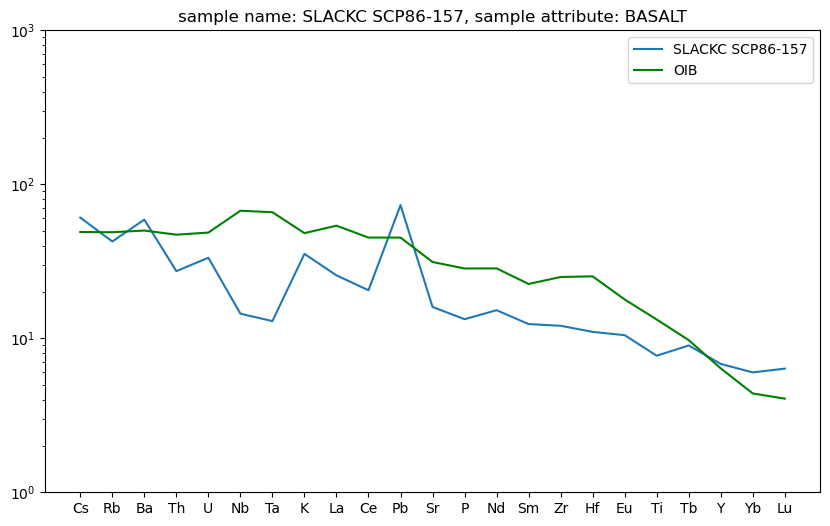

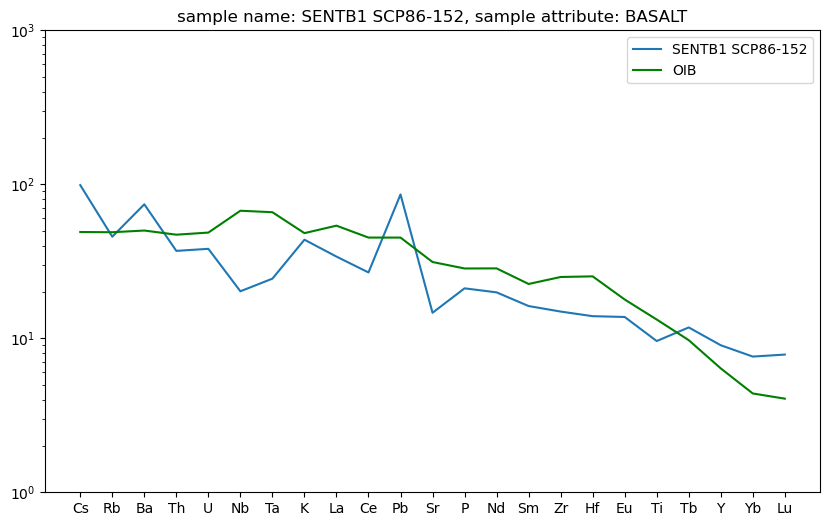

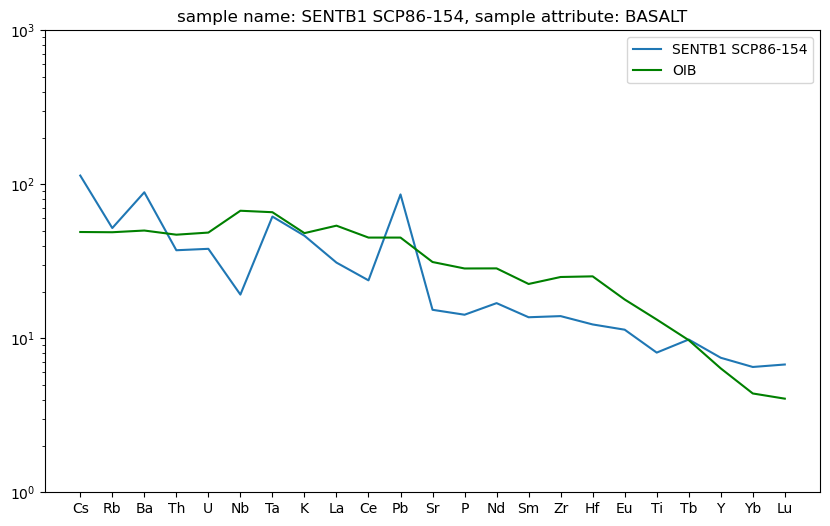

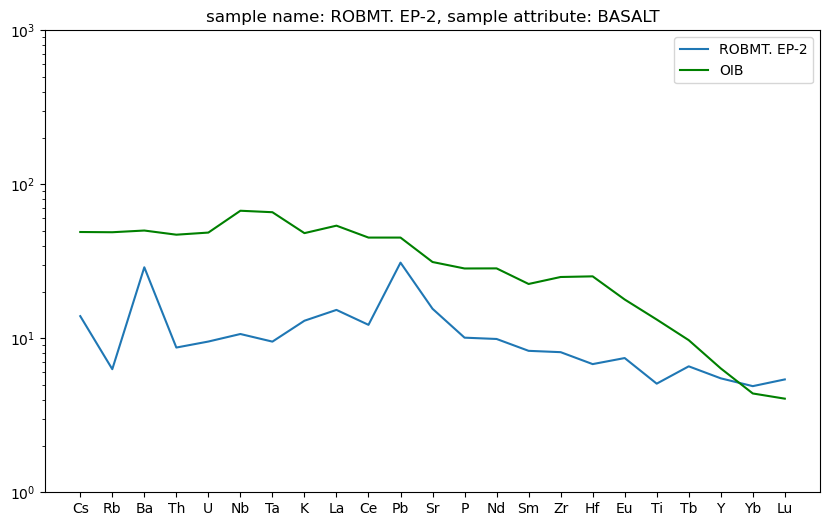

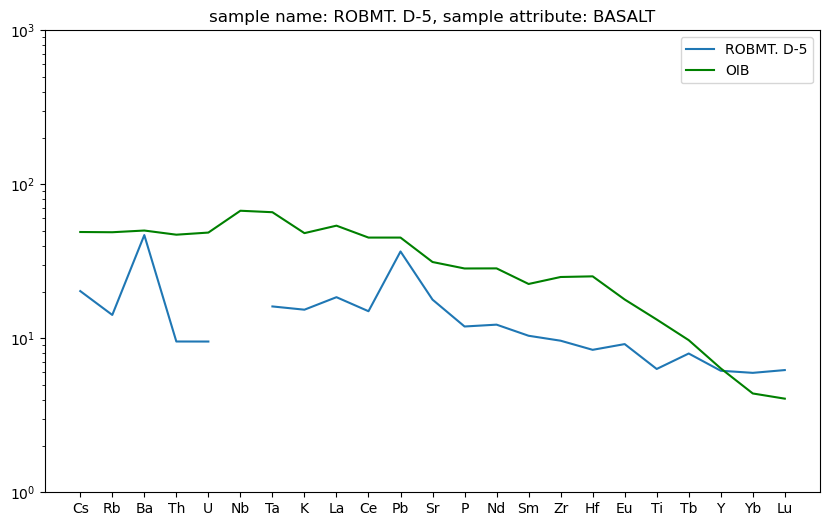

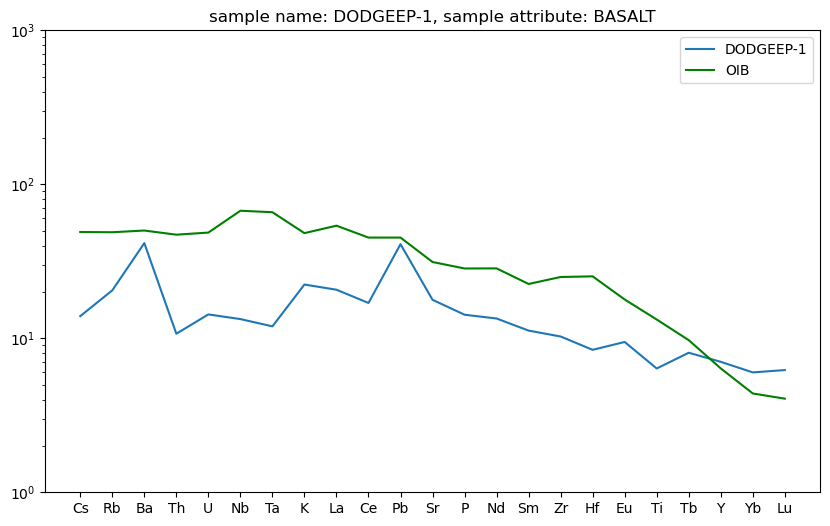

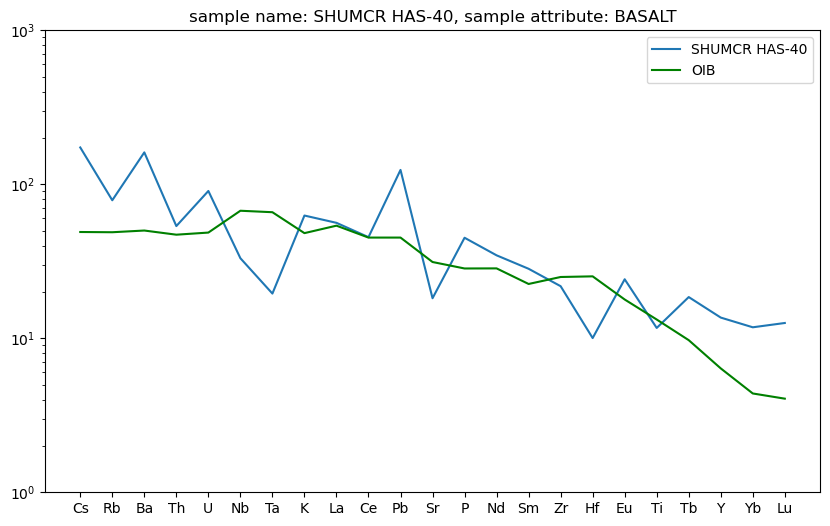

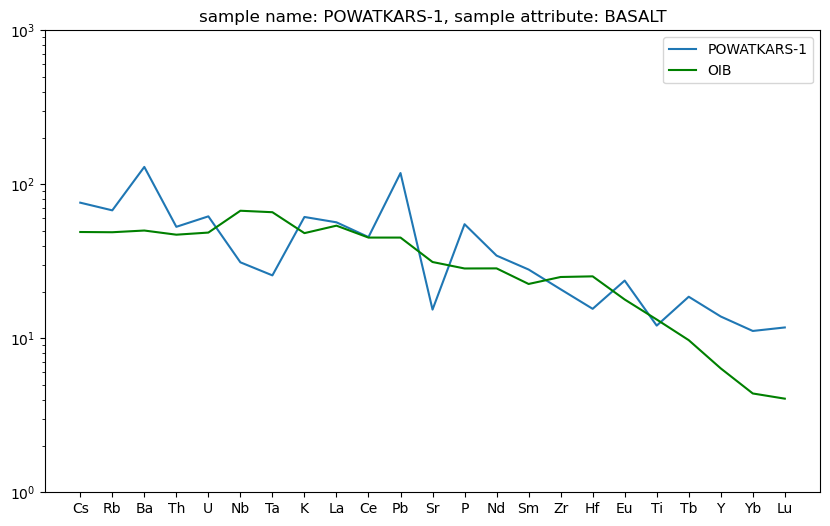

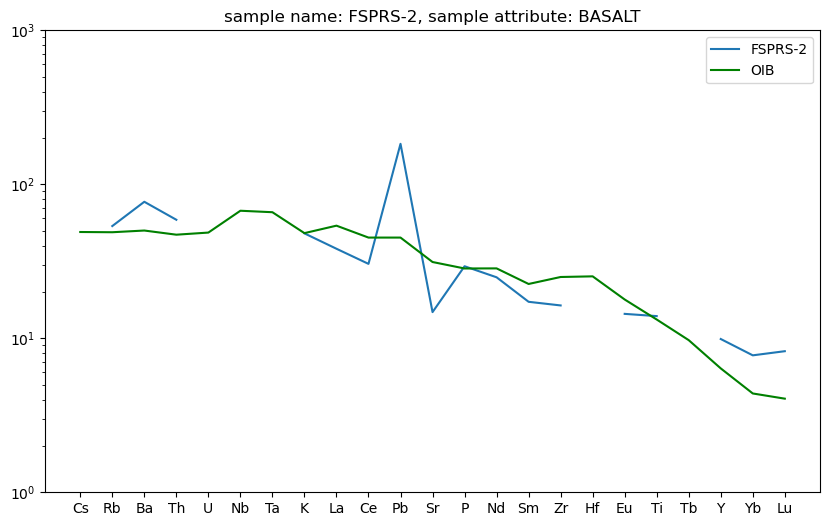

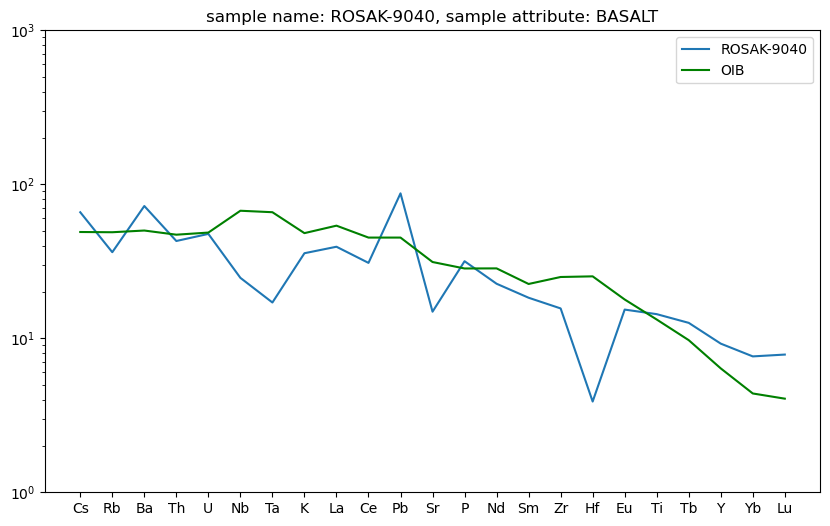

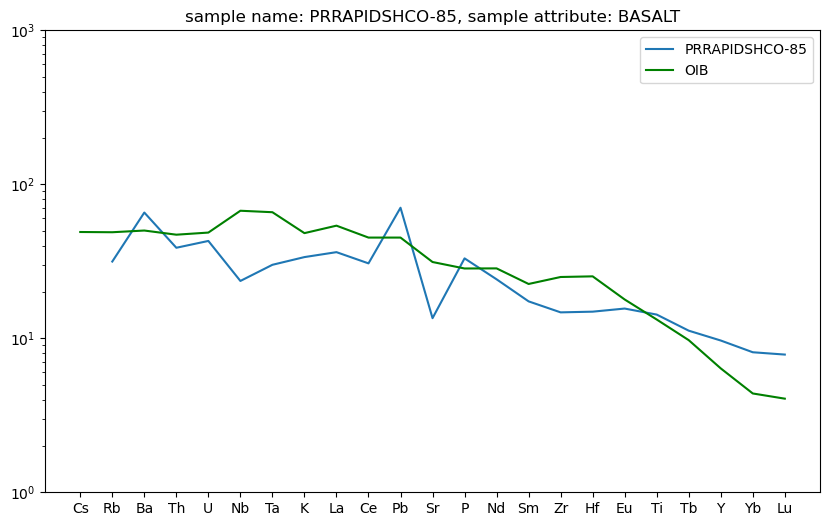

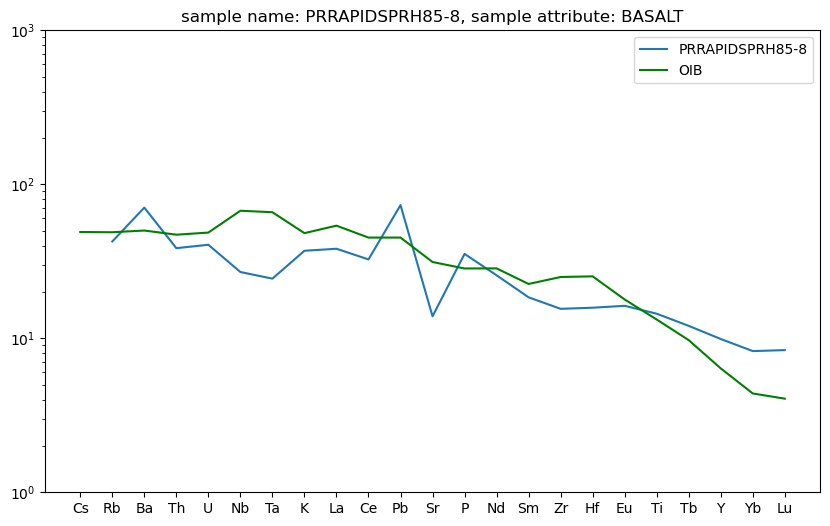

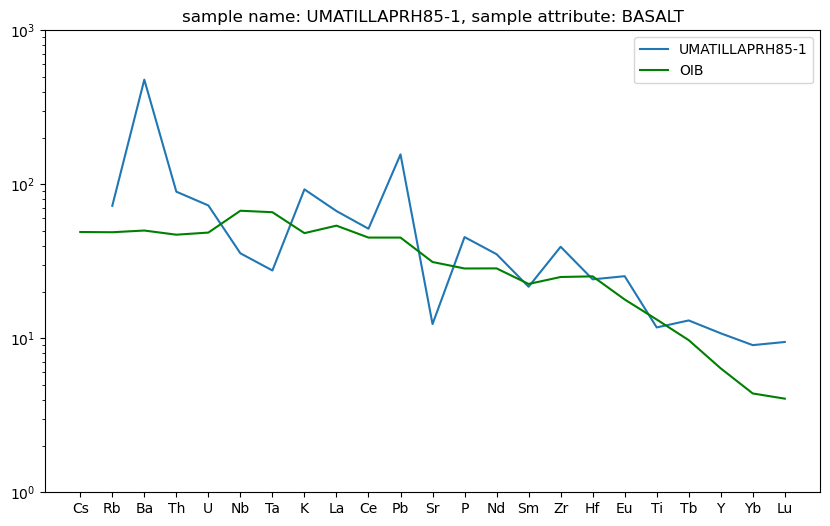

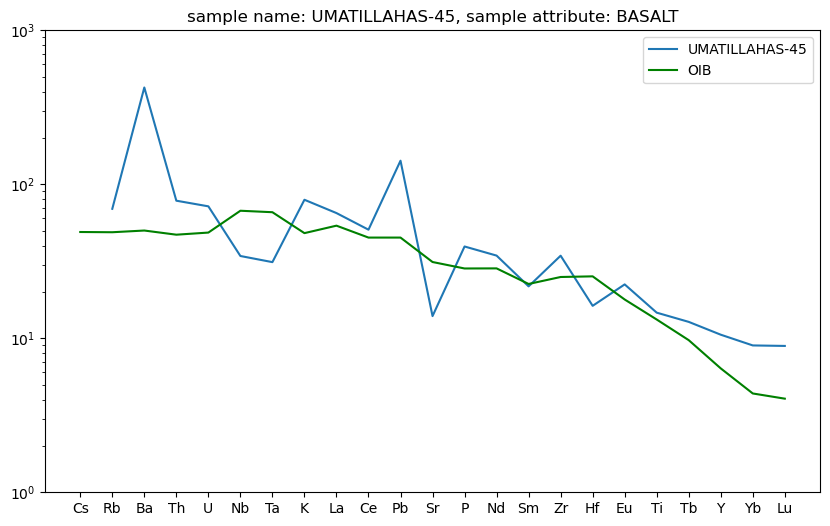

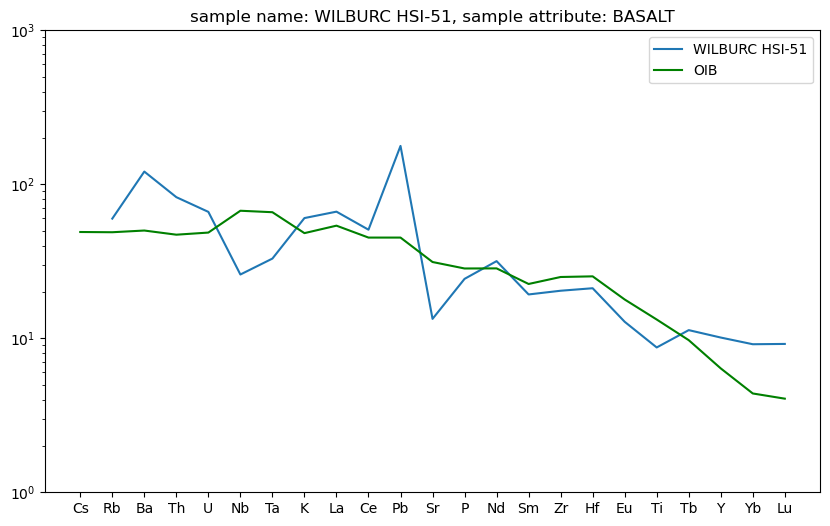

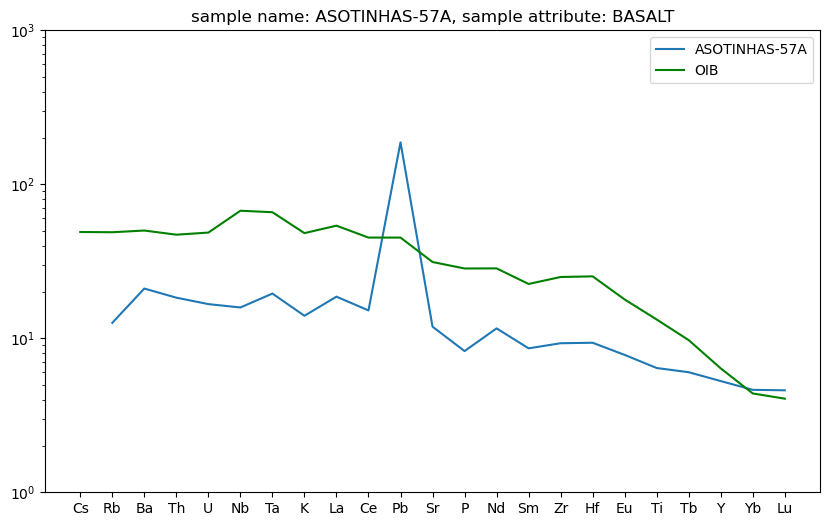

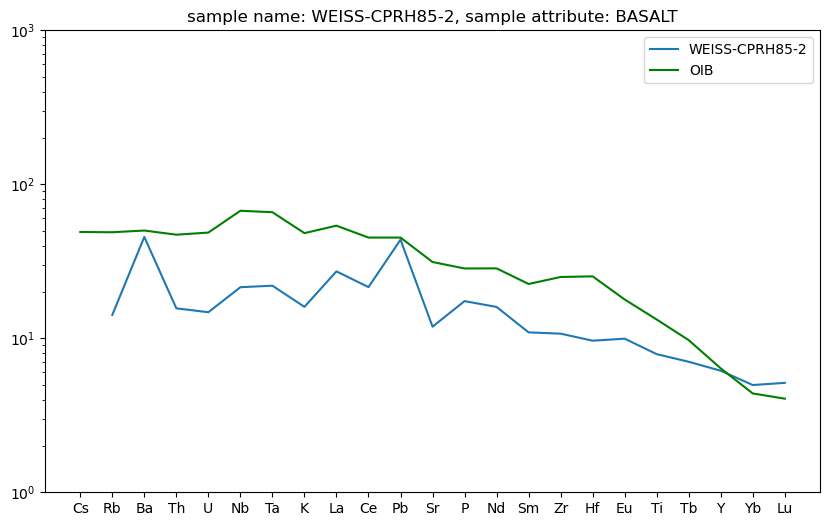

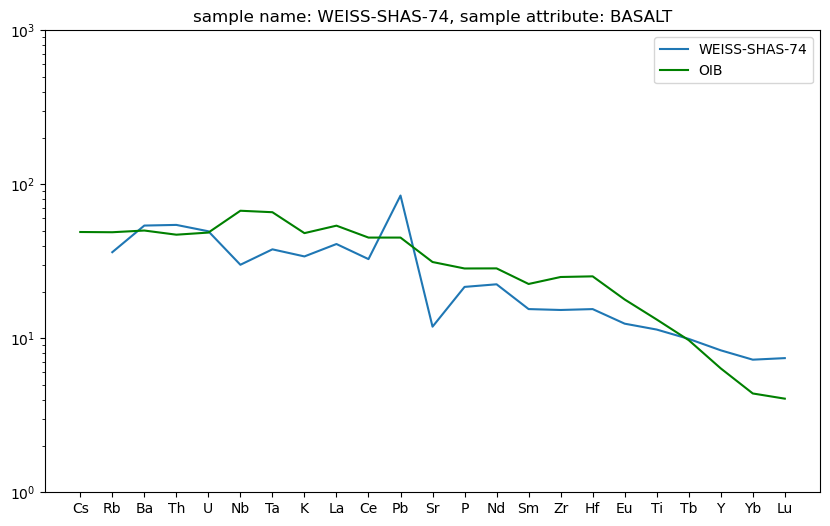

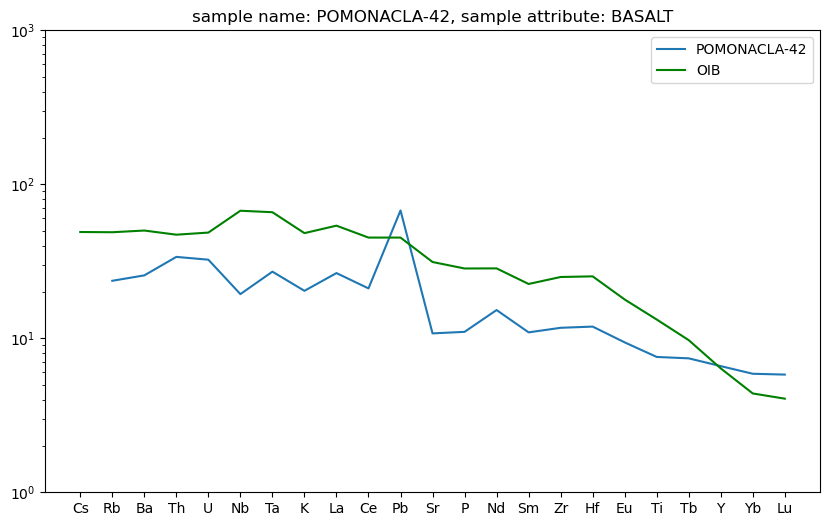

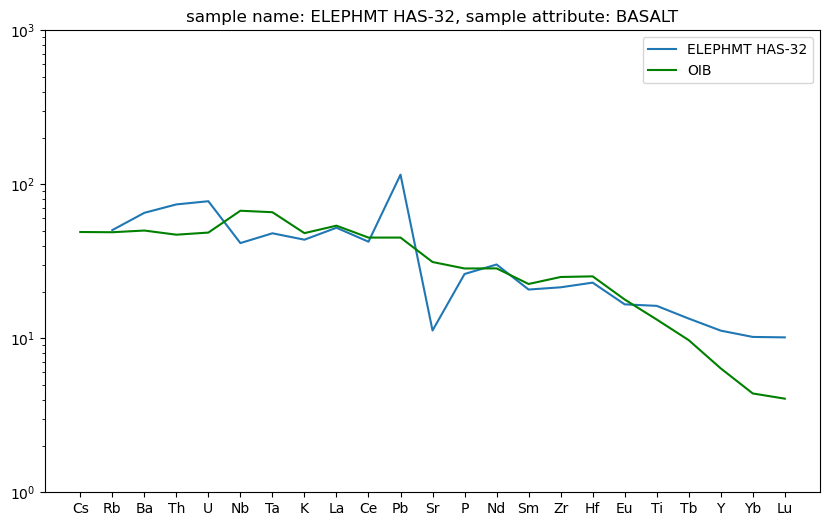

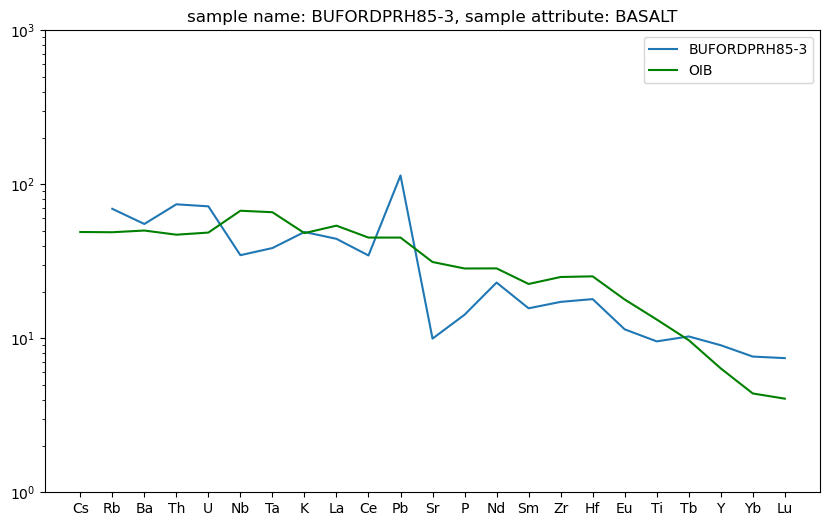

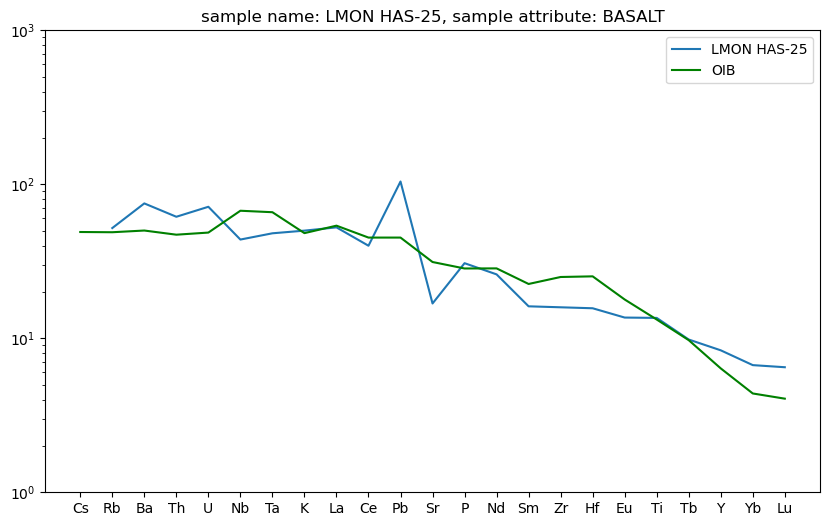

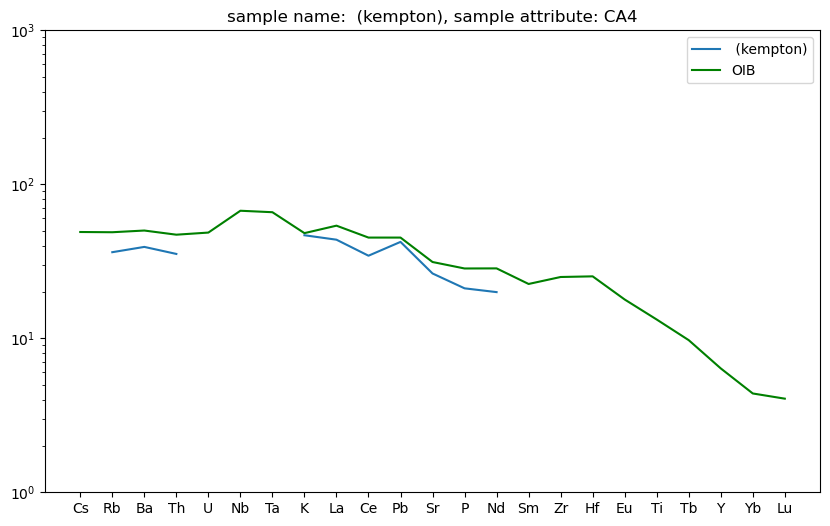

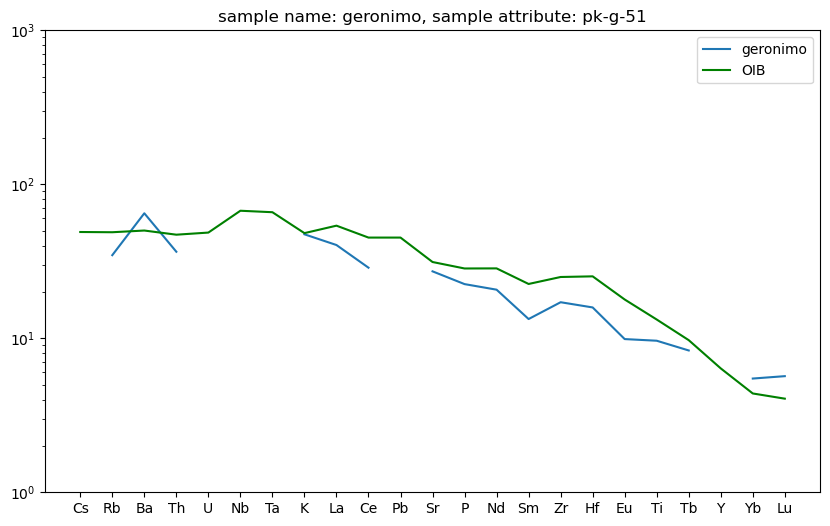

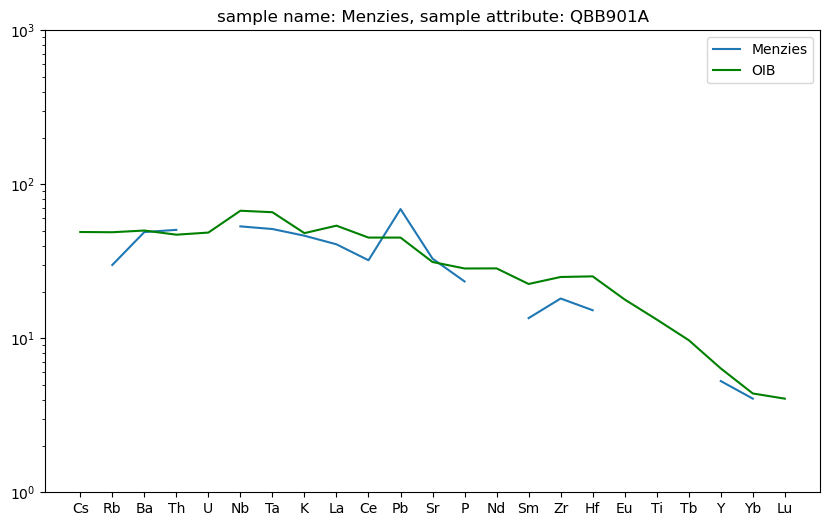

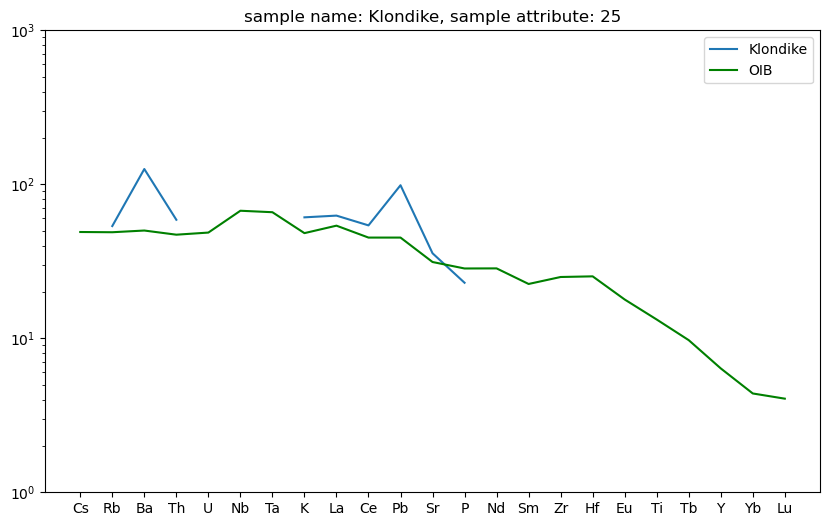

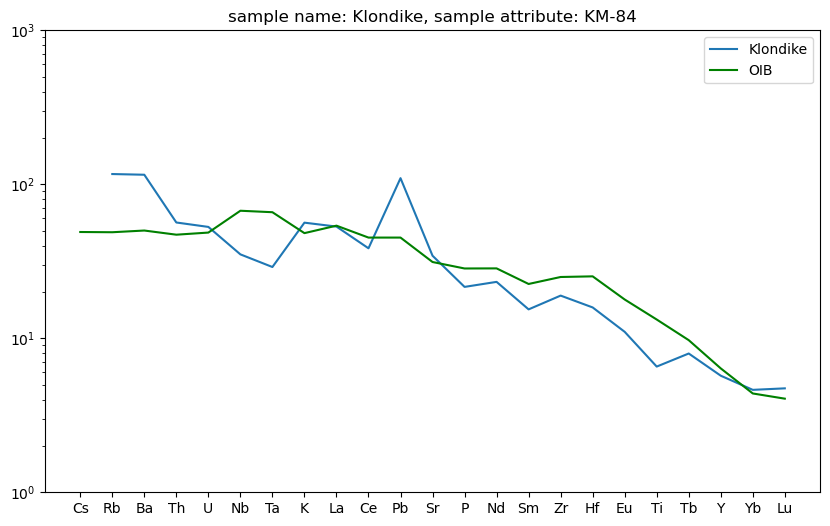

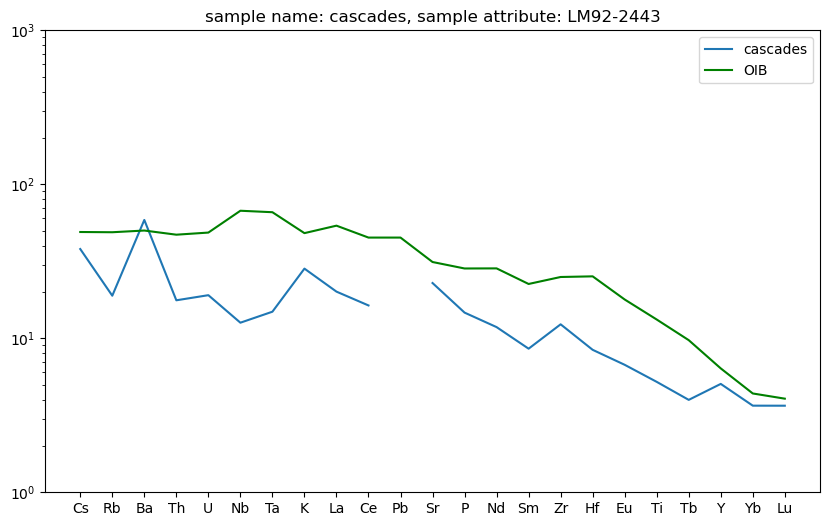

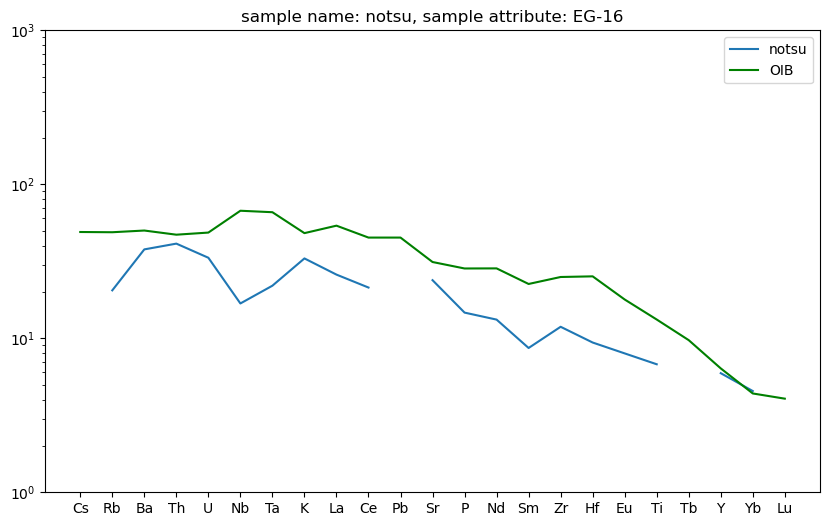

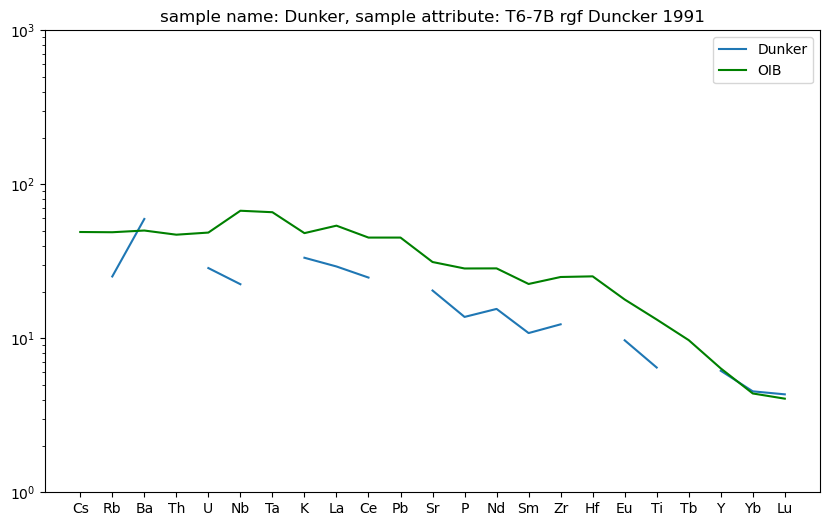

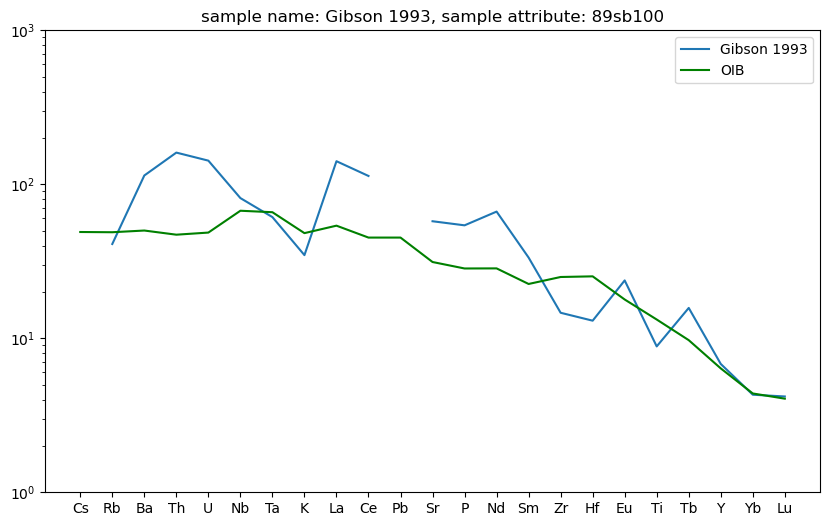

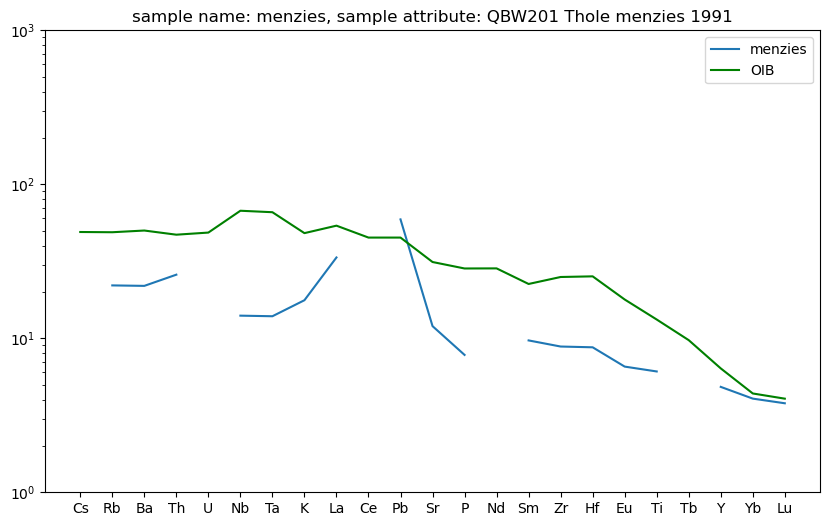

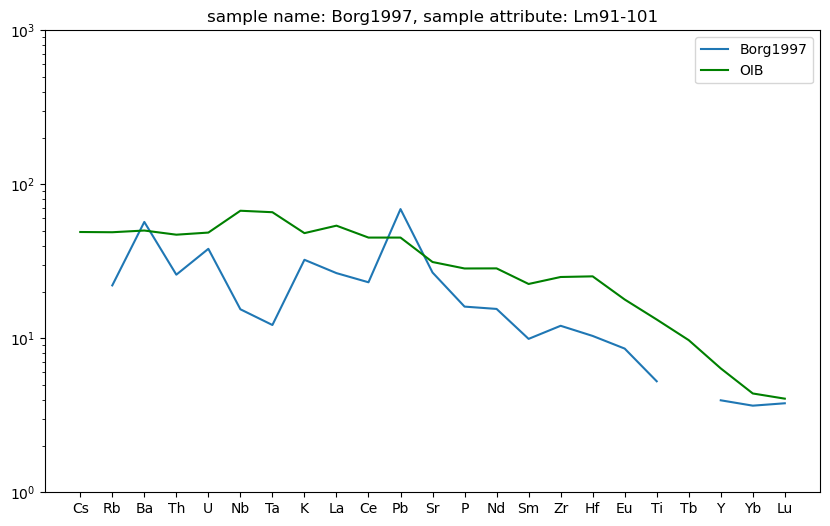

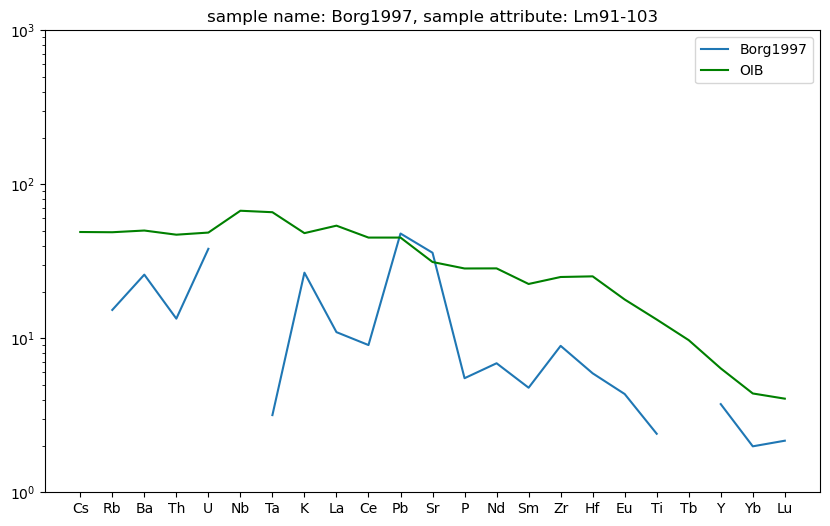

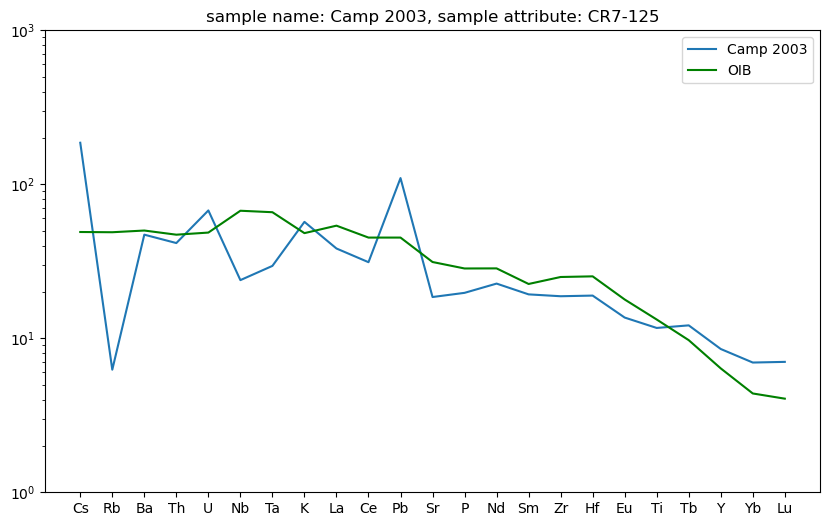

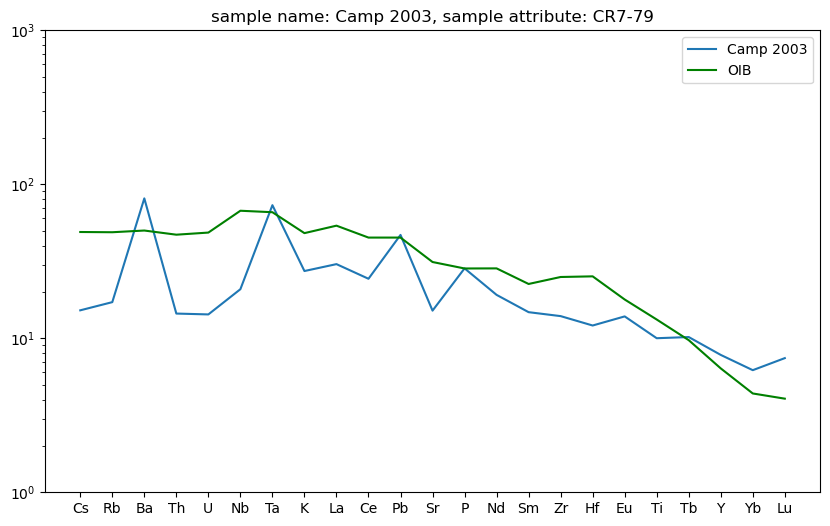

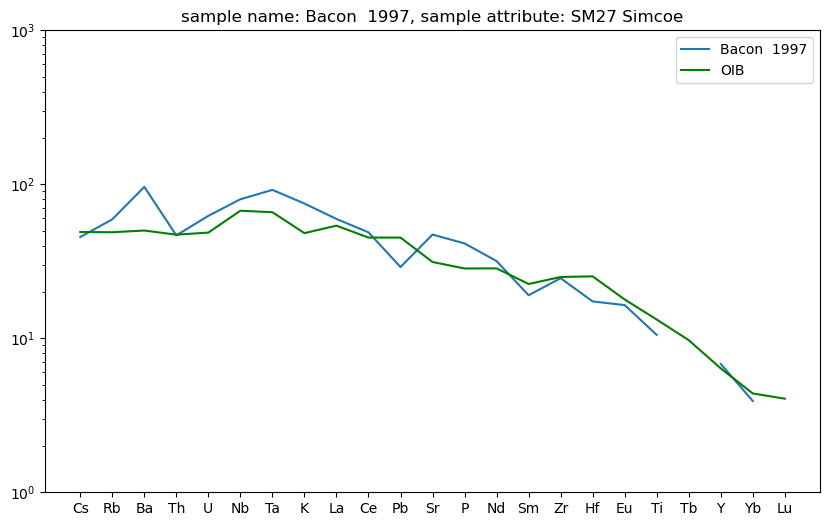

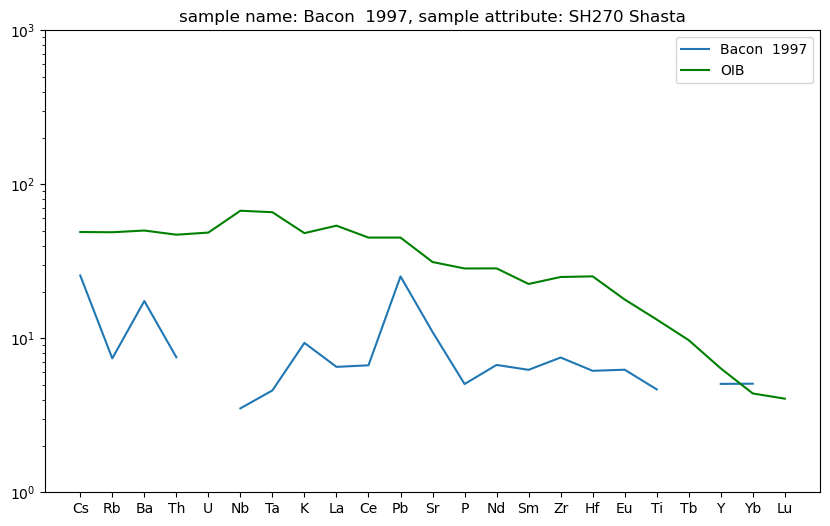

In [14]:
for i in range(normalised_df.columns.size):
    plt.figure(figsize=(10,6))
    plt.plot(dataset["Elements"], normalised_df[i], label=f"{name_row[i]}")
    plt.plot(dataset["Elements"], dataset.iloc[:,3], color="green", label="OIB") #OIB
    plt.title(f"sample name: {name_row[i]}, sample attribute: {attribute_row[i]}")
    plt.yscale('log')
    plt.ylim(1e0,1e3)
    plt.legend()
    plt.show()